### <font color = green> **ANALYSIS OF O-LEVEL MATHEMATICS EXAMS SCORE OF SECONDARY 4/5 STUDENTS**</br></font>

##### <font color='blue'>**IMPORTANT INFORMATION ABOUT O-LEVEL AND SECONDARY SCHOOL EDUCATION IN SINGAPORE**</font><br>

**CONTEXT:** </br>
- In Singapore, "O-level" stands for the Singapore-Cambridge General Certificate of Education Ordinary Level. </br>
- It is a major national exam taken by students at the end of Secondary 4 or Secondary 5. </br>
- The results decide which schools or programs students can join next, such as Junior Colleges or Polytechnics. </br>

**KEY DETAILS:** </br>
- Age and Timing: Students usually take the exams at age 16 in October and November. </br>
- Secondary 4 / 5: Typically 15 to 17 years old depending on whether they are on the 4-year Express track or 5-year Normal Academic/Technical track. </br>
- Who runs it: Managed by the Ministry of Education (MOE), the Singapore Examinations and Assessment Board (SEAB), and Cambridge International Education. </br>
- Subjects: Students take 5 to 9 subjects, including English, Mother Tongue, Math, Science, and Humanities. </br>

**GRADING AND SCORING:** </br>
- Grades: Scored from A1 (best) to F9 (fail). A grade of C6 or better is a pass. </br>
- Aggregates: Students use scores like L1R5 (Language 1 + 5 Relevant subjects) or L1R4 to apply for post-secondary education. Lower numbers are better. </br>

**RAW EXAM MARKS OR PERCENTAGES:** </br>
- If the range represents the actual marks scored out of 100 on a school mock exam or the estimated raw percentage on the national GCE O-Level Mathematics papers: </br>
- 32 out of 100: This represents a failing score (typically an E8 or F9 grade). It is completely plausible for a student who is struggling significantly with the syllabus or who leaves major sections of the paper blank. </br>
- 100 out of 100: This represents a perfect score. In O-Level Mathematics (especially Elementary Mathematics), achieving full marks or very close to it is common among top-performing students due to the precise, objective nature of the marking scheme. </br>

**CLASS AND COHORT BREAKDOWN:** </br>
- Average Class Size: ~33 students per form class across secondary levels. </br>
- Secondary 4 Cohort: ~39,600 students nationally (spanning Express, Normal (Academic), and Normal (Technical) streams). </br>
- Secondary 5 Cohort: ~2,000 students nationally (restricted to Normal (Academic) students who progress past their N-Levels). </br>

**TYPICAL DAILY SCHEDULE STRUCTURE:** </br>
- Morning Assembly: 7:30 AM – 7:45 AM (Flag raising and attendance taking). </br>
- Recess / Lunch Breaks: 30 to 40 minutes total, usually spaced out mid-morning. </br>
- Standard Dismissal: 2:15 PM – 3:30 PM on most days. 
- Upper secondary students taking extra subjects (e.g., Higher Mother Tongue, pure sciences, or coursework) often stay until 4:00 PM or later on certain weekdays. </br>

**EXTENDED HOURS & AFTER-SCHOOL ACTIVITIES:** </br>
- The academic day frequently extends past standard classroom hours for graduating students: </br>
- Co-Curricular Activities (CCA): Occur 1 to 2 days a week, typically running from 3:30 PM to 6:00 PM.  </br>
- Note that many Sec 4/5 students stand down from CCAs by April or May to focus entirely on their examinations. </br>
- Remedial & Extension Classes: Graduating classes regularly attend structured academic support or preparatory mock exams after regular hours, lasting until 4:30 PM or 5:00 PM </br>

**INDEPENDENT STUDY & TUITION:** </br>
- A 0-20 study hours range referring to homework, tuition, and exam revision outside of school hours is a very accurate reflection of a graduating student's life. </br>
- 0 hours: This only happens during rare school holiday breaks or immediately after major exams. </br>
- 10 to 20 hours: This is the standard reality for most upper secondary students.  </br>
- Spreading 15 hours across a week equates to roughly 2 hours on weekdays and 2.5 hours a day on weekends, which is typical for O-Level or SEC preparation.  </br>

**ATTENDANCE RATE:** </br>
- For a typical student in Singapore, the actual realistic attendance range is tightly bound: </br>
- 95% – 100% (Excellent): The norm for the vast majority of graduating students. </br>
- 90% – 95% (Acceptable): Generally permissible if the minor absences are covered by official Medical Certificates (MCs) or valid letters from parents for compassionate leave. </br>
- Below 90% (Flagged): Any drop below this line immediately triggers an internal school review, requiring formal documentation and meetings with parents. </br>

**Why 40% Attendance is Implausible?**
- Strict MOE Tracking: The Ministry of Education (MOE) monitors school attendance meticulously. Statistically, only about 2% of secondary school students miss more than 10% of school days (falling below 90% attendance) without a valid medical or personal reason.
- Severe Truancy Interventions: A student dropping to a 40% attendance rate implies they are missing roughly three out of every five school days. This status activates the school's welfare framework, involving school counselors, disciplinary actions, home visits, and multi-agency support via programs like the MOE UPLIFT Initiative.
- National Examination Eligibility: Secondary 4 and 5 are graduating years. Mainstream schools and national examination boards generally require high attendance to certify that a student has completed the academic syllabus. Sustained unexcused absences can result in a student being barred from sitting for major national exams like the GCE O-Levels or SEC, or being retained to repeat the academic year.

### <font color = green> **PART A: DATA PREPARATION & CLEAN-UP**</br></font>

In [145]:
#Define required libraries
import sqlite3
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LinearRegression

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_validate, KFold

# Creation of folders for project files
from pathlib import Path

# Output Folder | Create if it does not exist yet
output_folder = Path('data/')
output_folder.mkdir(exist_ok=True)

# Charts Folder | Create if it does not exist yet
charts_folder = Path('charts/')
charts_folder.mkdir(exist_ok=True)

##### **STEP 1. Download the database manually and connect to the database and explore table(s)**

Open the database URL in the browser and save the downloaded file manually. </br>

URL: https://techassessment.blob.core.windows.net/aiap-preparatory-bootcamp/score.db </br>
Path: data/score.db </br>

In [146]:
# Connect to the database and explore the table(s)
conn = sqlite3.connect("data/score.db")

tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)

display(tables)

,name
0,score


##### **STEP 2. Load the score table to a Pandas DataFrame**

In [147]:
# Dataframes:
# a. df_raw = original data from the source
# b. df = working copy for EDA

df_raw = pd.read_sql_query("SELECT * FROM score", conn)

df = df_raw.copy()

df.head(10)

,index,number_of_siblings,direct_admission,CCA,learning_style,student_id,gender,tuition,final_test,n_male,n_female,age,hours_per_week,attendance_rate,sleep_time,wake_time,mode_of_transport,bag_color
0,0,0,Yes,Sports,Visual,ACN2BE,Female,No,69.0,14.0,2.0,16.0,10.0,91.0,22:00,6:00,private transport,yellow
1,1,2,No,Sports,Auditory,FGXIIZ,Female,No,47.0,4.0,19.0,16.0,7.0,94.0,22:30,6:30,private transport,green
2,2,0,Yes,None,Visual,B9AI9F,Male,No,85.0,14.0,2.0,15.0,8.0,92.0,22:30,6:30,private transport,white
3,3,1,No,Clubs,Auditory,FEVM1T,Female,Yes,64.0,2.0,20.0,15.0,18.0,NaN,21:00,5:00,public transport,yellow
4,4,0,No,Sports,Auditory,AXZN2E,Male,No,66.0,24.0,3.0,16.0,7.0,95.0,21:30,5:30,public transport,yellow
5,5,0,No,Arts,Visual,BA6R14,Female,No,57.0,9.0,12.0,15.0,11.0,96.0,22:30,6:30,private transport,red
6,6,2,Yes,None,Visual,D5WGTI,Male,No,69.0,12.0,3.0,16.0,15.0,93.0,21:30,5:30,public transport,green
7,7,0,No,Sports,Visual,HTP8CW,Male,No,76.0,20.0,2.0,15.0,3.0,97.0,21:00,5:00,public transport,green
8,8,0,No,Arts,Auditory,U3YRTC,Male,No,57.0,20.0,7.0,15.0,15.0,98.0,22:00,6:00,private transport,red
9,9,2,No,Arts,Auditory,3MOMA6,Male,Yes,60.0,13.0,9.0,16.0,16.0,NaN,22:30,6:30,private transport,green


##### **STEP 3. Perform Exploratory Data Analysis on the score table**

##### A. Check number of rows and columns

In [148]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 15900
Number of columns: 18


##### B. Check column names, dataypes, non-null counts

In [149]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15900 entries, 0 to 15899
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   index               15900 non-null  int64  
 1   number_of_siblings  15900 non-null  int64  
 2   direct_admission    15900 non-null  str    
 3   CCA                 15900 non-null  str    
 4   learning_style      15900 non-null  str    
 5   student_id          15900 non-null  str    
 6   gender              15900 non-null  str    
 7   tuition             15900 non-null  str    
 8   final_test          15405 non-null  float64
 9   n_male              15900 non-null  float64
 10  n_female            15900 non-null  float64
 11  age                 15900 non-null  float64
 12  hours_per_week      15900 non-null  float64
 13  attendance_rate     15122 non-null  float64
 14  sleep_time          15900 non-null  str    
 15  wake_time           15900 non-null  str    
 16  mode_of_transpo

##### C. Check for missing values

In [150]:
df.isnull().sum()

index                   0
number_of_siblings      0
direct_admission        0
CCA                     0
learning_style          0
student_id              0
gender                  0
tuition                 0
final_test            495
n_male                  0
n_female                0
age                     0
hours_per_week          0
attendance_rate       778
sleep_time              0
wake_time               0
mode_of_transport       0
bag_color               0
dtype: int64

##### C. Check for duplicate records

In [151]:
# Check for duplicate records
print("Duplicate rows:", df.duplicated().sum())

# Check for duplicate index
print("Duplicate index:", df["index"].duplicated().sum())

# Check for duplicate student IDs
print("Duplicate student IDs:", df["student_id"].duplicated().sum())

Duplicate rows: 0
Duplicate index: 0
Duplicate student IDs: 900


##### D. View summary statistics (For Numerical columns)

In [152]:
df.describe()

,index,number_of_siblings,final_test,n_male,n_female,age,hours_per_week,attendance_rate
count,15900.000000,15900.000000,15405.000000,15900.000000,15900.000000,15900.000000,15900.000000,15122.000000
mean,7949.500000,0.886541,67.165401,13.880000,8.906038,15.213459,10.312579,93.270268
std,4590.078975,0.751346,13.977879,6.552584,6.663852,1.758941,4.461861,7.984230
min,0.000000,0.000000,32.000000,0.000000,0.000000,-5.000000,0.000000,40.000000
25%,3974.750000,0.000000,56.000000,10.000000,4.000000,15.000000,7.000000,92.000000
50%,7949.500000,1.000000,68.000000,14.000000,8.000000,15.000000,9.000000,95.000000
75%,11924.250000,1.000000,78.000000,18.000000,13.000000,16.000000,14.000000,97.000000
max,15899.000000,2.000000,100.000000,31.000000,31.000000,16.000000,20.000000,100.000000


##### E. View the values of the Categorical columns

In [153]:
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print("=" * 50)
    print(f"Column: {column}")
    print("=" * 50)

    # Value counts
    print(df[column].value_counts(dropna=False))

    # % Breakdown
    print("\nPercentage Breakdown:")
    print(round(df[column].value_counts(normalize=True, dropna=False) * 100, 2))

    # # of Unique Values
    print("\nNumber of Unique Values:")
    print(df[column].nunique())

    print("\n")

Column: direct_admission
direct_admission
No     11195
Yes     4705
Name: count, dtype: int64

Percentage Breakdown:
direct_admission
No     70.41
Yes    29.59
Name: proportion, dtype: float64

Number of Unique Values:
2


Column: CCA
CCA
Clubs     3912
Sports    3865
None      3829
Arts      3785
CLUBS      143
NONE       130
ARTS       128
SPORTS     108
Name: count, dtype: int64

Percentage Breakdown:
CCA
Clubs     24.60
Sports    24.31
None      24.08
Arts      23.81
CLUBS      0.90
NONE       0.82
ARTS       0.81
SPORTS     0.68
Name: proportion, dtype: float64

Number of Unique Values:
8


Column: learning_style
learning_style
Auditory    9132
Visual      6768
Name: count, dtype: int64

Percentage Breakdown:
learning_style
Auditory    57.43
Visual      42.57
Name: proportion, dtype: float64

Number of Unique Values:
2


Column: student_id
student_id
AXZN2E    2
T4U89N    2
G0JBVS    2
HJ6Y5P    2
PQ059G    2
         ..
XPECN2    1
7AMC7S    1
XKZ6VN    1
2OU4UQ    1
D9OKLV    1


/var/folders/5x/h0y6d2h9185gj8rngbqzdl4r0000gn/T/ipykernel_2501/900568097.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


##### <font color='blue'>**SUMMARY OF DATASET CHARACTERISTICS:**</font><br>

Number of rows: 15,900 </br>
- 0 duplicate rows
- index: unique running number

Number of columns: 18 </br>
- 8 numerical
- 10 string (categorical)

##### <font color='blue'>**KEY OBSERVATIONS FOR NUMERICAL COLUMNS:**</font><br>

**DATA ISSUES:** </br>
1. final_test: Target variable has 495 missing records (3.11%)
2. attendance_rate: 778 missing records (4.9%)
3. age: minimum has a value of -5 --Invalid data: For further investigation
4. age range: -5 to 16 years old

**DATA RANGES & OTHER OBSERVATIONS:**
1. index: 0 to 16899 and no duplicate records >> Unique running number
1. number_of_siblings: 0 to 2 >> Plausible
2. final_test range: 32 to 100 >> Plausible
3. n_male: 0 to 31 >> Plausible
4. n_female: 0 to 31 >> Plausible
5. age: mean is 15 >> Plausible
6. hours_per_week range: 0 to 20 study hours >> Plausible
7. attendance_rate range: 40% to 100% >> Plausible range is 90%-100% <font color='red'>KIV how attendance rate below 90% affects final_test</font>

##### <font color='blue'>**KEY OBSERVATIONS FOR TEXT COLUMNS:**</font><br>

**DATA ISSUES:** </br>
1. student ID: 900 duplicate records (5.66%) --For further investigation

**TO BE STANDARDISED:**
1. CCA
2. tuition

**TO BE FEATURE-ENGINEERED:**
1. sleep_time
2. wake_time

**No further data clean-up or transformation to be done**
1. direct_admission: Yes / No
2. learning_style: Auditory / Visual
3. gender: Male / Female
4. mode_of_transport: public transport / private transport / walk
5. bag_color: yellow / green / black / blue / red / white


##### **Step 4. Investigate columns with data issues**
Workflow: Detect → Investigate → Decide → Document → Transform </br>

**<font color='red'>1. DUPLICATE STUDENT IDS**</font> </br>

Number of rows: 900 </br>
% of data: 5.66% </br>

In [154]:
# Number of unique students
print("Total # of Rows:", len(df))
print("Unique student IDs:", df["student_id"].nunique())

# Show all records belonging to duplicated student IDs
duplicate_students = df[
    df["student_id"].duplicated(keep=False)
].sort_values("student_id")

duplicate_students.head(20)

Total # of Rows: 15900
Unique student IDs: 15000


,index,number_of_siblings,direct_admission,CCA,learning_style,student_id,gender,tuition,final_test,n_male,n_female,age,hours_per_week,attendance_rate,sleep_time,wake_time,mode_of_transport,bag_color
5534,5534,0,No,Clubs,Auditory,00811H,Female,Yes,88.0,21.0,4.0,15.0,8.0,92.0,23:00,7:00,walk,green
12290,12290,0,No,Clubs,Auditory,00811H,Female,Yes,88.0,21.0,4.0,15.0,8.0,92.0,23:00,7:00,walk,white
12270,12270,1,No,Arts,Visual,0195IO,Female,No,52.0,8.0,22.0,16.0,15.0,99.0,22:00,6:00,private transport,yellow
13541,13541,1,No,Arts,Visual,0195IO,Female,No,52.0,8.0,22.0,16.0,15.0,99.0,22:00,6:00,private transport,yellow
4303,4303,0,No,Clubs,Auditory,02RSAH,Female,Yes,64.0,12.0,9.0,15.0,17.0,97.0,22:00,6:00,private transport,yellow
9172,9172,0,No,Clubs,Auditory,02RSAH,Female,Yes,64.0,12.0,9.0,15.0,17.0,97.0,22:00,6:00,private transport,green
8641,8641,0,No,Arts,Auditory,0FC4RY,Female,No,68.0,23.0,4.0,15.0,6.0,NaN,23:00,7:00,walk,blue
9791,9791,0,No,Arts,Auditory,0FC4RY,Female,No,68.0,23.0,4.0,15.0,6.0,100.0,23:00,7:00,walk,yellow
1405,1405,0,Yes,None,Visual,0JUGAF,Female,No,84.0,18.0,2.0,16.0,10.0,94.0,23:00,7:00,walk,red
6339,6339,0,Yes,None,Visual,0JUGAF,Female,No,84.0,18.0,2.0,16.0,10.0,94.0,23:00,7:00,walk,yellow


In [155]:
# Count how many student IDs are appearing once, twice and more than 2x
id_counts = df["student_id"].value_counts()

print("IDs appearing once:", (id_counts == 1).sum())
print("IDs appearing twice:", (id_counts == 2).sum())
print("IDs appearing >2 times:", (id_counts > 2).sum())

IDs appearing once: 14100
IDs appearing twice: 900
IDs appearing >2 times: 0


In [156]:
# Identify which columns differ within duplicated student IDs

comparison = (
    df[df["student_id"].duplicated(keep=False)]
    .groupby("student_id")
    .nunique(dropna=False)
)

difference_counts = (
    (comparison.drop(columns="index") > 1)
    .sum()
    .sort_values(ascending=False)
)

display(difference_counts)

bag_color             729
attendance_rate        90
final_test             52
number_of_siblings      0
direct_admission        0
CCA                     0
learning_style          0
gender                  0
tuition                 0
n_male                  0
n_female                0
age                     0
hours_per_week          0
sleep_time              0
wake_time               0
mode_of_transport       0
dtype: int64

In [157]:
# Count the number of records with duplicated student IDs that have different values in other fields

conflicting_ids = comparison.drop(columns="index").index[
    (comparison.drop(columns="index") > 1).any(axis=1)
]

print(
    "Duplicated students with conflicting data:",
    len(conflicting_ids)
)

Duplicated students with conflicting data: 761


##### <font color='blue'>**KEY OBSERVATIONS for Duplicated records of Student ID:**</font><br>

1. bag_color: 729 records | 80% of the duplicated records >> For further investigation
2. attendance_rate: 90 records >> For further investigation
3. final_test: 52 records >> For further investigation
4. Remaining fields: Identical within duplicate pairs >> No further action required

**<font color='red'>a. Investigate the duplicate student ID records with different bag_color values (729 records)**</font> </br>

In [158]:
# View the data of the duplicate student ID records with different bag_color values
attendance_conflicts = df[
    df["student_id"].isin(
        comparison.index[comparison["bag_color"] > 1]
    )
].sort_values("student_id")

attendance_conflicts[

    ["student_id", "bag_color"]
].head(20)

,student_id,bag_color
5534,00811H,green
12290,00811H,white
4303,02RSAH,yellow
9172,02RSAH,green
8641,0FC4RY,blue
9791,0FC4RY,yellow
1405,0JUGAF,red
6339,0JUGAF,yellow
9156,0K5LDV,white
15721,0K5LDV,red


In [159]:
# View bag_color values per student_id

attendance_summary = (
    attendance_conflicts
    .groupby("student_id")["bag_color"]
    .agg(list)
)

#Export duplicates_bag_color to CSV file and save inside data folder
attendance_summary.to_csv(
    output_folder / "duplicates_bag_color.csv",
    index=False
)

In [160]:
# Check if exam scores differ materially across bag colours:
bag_analysis = (
    df.groupby("bag_color")["final_test"]
      .agg(["count", "mean", "median", "std"])
      .round(2)
      .sort_values("mean", ascending=False)
)

bag_analysis

,count,mean,median,std
bag_color,,,,
red,2541,67.43,68.0,13.96
yellow,2658,67.37,68.0,14.14
black,2570,67.36,68.0,13.87
white,2531,67.14,68.0,13.91
blue,2550,67.11,68.0,13.83
green,2555,66.56,67.0,14.13


In [161]:
# Calculate the range of group means:

mean_range = (
    bag_analysis["mean"].max()
    - bag_analysis["mean"].min()
)

print("Difference between highest and lowest mean:", mean_range)

Difference between highest and lowest mean: 0.8700000000000045


##### <font color='blue'>**KEY OBSERVATIONS for bag_color:**</font><br>

1. Data reliability: Among the 900 duplicated student IDs, 729 (81%) have inconsistent bag_color values. Therefore, it is not a stable characteristic in this dataset.
2. Empirical relevance: Average final-test scores vary by only 0.87 points across the 6 bag colours, against within-colour standard deviations of approximately 14 points.
3. Domain relevance: bag_color showed limited analytical relevance to mathematics performance.
4. Decision: To exclude this feature from predictive modelling to reduce noise and the risk of spurious relationships.

Spurious Relationship: An apparent connection between two variables that looks meaningful in the data but is actually coincidental, caused by another hidden factor, or unlikely to hold in new data. </br>
The trap with bag_color is thinking that any difference in average scores means the variable has predictive meaning; your results show small differences, but that does not mean bag colour has anything to do with mathematics ability. </br>

For example, Students with red bags scored 0.87 points higher on average than students with green bags. </br>

It would be unreasonable to conclude that “Carrying a red bag improves mathematics performance.” </br>
That would confuse association with causation. </br>

**<font color='red'>b. Investigate the duplicate student ID records with different attendance_rate values (90 records)**</font> </br>

In [162]:
# View the data of the duplicate student ID records with different attendance_rate values

attendance_conflicts = df[
    df["student_id"].isin(
        comparison.index[comparison["attendance_rate"] > 1]
    )
].sort_values("student_id")

attendance_conflicts[
    ["student_id", "attendance_rate"]
].head(20)

,student_id,attendance_rate
8641,0FC4RY,NaN
9791,0FC4RY,100.0
11598,0VTYP7,99.0
12166,0VTYP7,NaN
8240,11RQTT,NaN
9683,11RQTT,98.0
5988,1ICS4I,NaN
13626,1ICS4I,95.0
6062,1KGNR8,88.0
15547,1KGNR8,NaN


In [163]:
# View attendance_rate values per student_id

attendance_summary = (
    attendance_conflicts
    .groupby("student_id")["attendance_rate"]
    .agg(list)
)

attendance_summary.head(90)

student_id
0FC4RY    [nan, 100.0]
0VTYP7     [99.0, nan]
11RQTT     [nan, 98.0]
1ICS4I     [nan, 95.0]
1KGNR8     [88.0, nan]
              ...     
Z8JTEX     [nan, 99.0]
ZGGAY0     [nan, 91.0]
ZGPEM4     [nan, 98.0]
ZGVJX8     [97.0, nan]
ZN5LCP     [nan, 90.0]
Name: attendance_rate, Length: 90, dtype: object

**<font color='red'>c. Investigate the duplicate student ID records with different final_test values (52 records)**</font> </br>

In [164]:
# View the data of the duplicate student ID records with different final_test values

final_test_conflicts = df[
    df["student_id"].isin(
        comparison.index[comparison["final_test"] > 1]
    )
].sort_values("student_id")

final_test_conflicts[
    ["student_id", "final_test"]
].head(20)

,student_id,final_test
2763,11V0BQ,NaN
12347,11V0BQ,79.0
905,2KKLZW,NaN
2204,2KKLZW,68.0
5039,2L5I46,80.0
14398,2L5I46,NaN
4897,34XQIE,NaN
12762,34XQIE,68.0
6520,3788PY,NaN
12663,3788PY,70.0


In [165]:
# View final_test values per student_id

final_test_summary = (
    final_test_conflicts
    .groupby("student_id")["final_test"]
    .agg(list)
)

final_test_summary.head(52)

student_id
11V0BQ    [nan, 79.0]
2KKLZW    [nan, 68.0]
2L5I46    [80.0, nan]
34XQIE    [nan, 68.0]
3788PY    [nan, 70.0]
3F0S0J    [nan, 55.0]
3V7O8I    [nan, 93.0]
49LXTX    [57.0, nan]
56L4FT    [44.0, nan]
65XOE2    [65.0, nan]
780QOV    [54.0, nan]
7IZB0S    [79.0, nan]
7XH8AD    [55.0, nan]
86KRE2    [nan, 84.0]
9GIGZA    [69.0, nan]
9HW69M    [66.0, nan]
AWF13G    [nan, 87.0]
C8LUW0    [nan, 70.0]
CDCHI6    [60.0, nan]
DO7UAH    [48.0, nan]
E2SD8H    [74.0, nan]
EP44QF    [98.0, nan]
GD80JW    [nan, 71.0]
GYH9Y9    [52.0, nan]
H7N3F1    [54.0, nan]
H9KJUR    [nan, 56.0]
HL7EEZ    [68.0, nan]
J759E4    [61.0, nan]
JGWFQ8    [nan, 93.0]
KC8YO4    [nan, 80.0]
KF8BR9    [nan, 48.0]
KNWL5Z    [nan, 73.0]
L410MC    [49.0, nan]
MP3IHL    [57.0, nan]
NAL739    [54.0, nan]
NWKTGU    [79.0, nan]
O8QXHI    [62.0, nan]
PNJV5Q    [74.0, nan]
SGCHM0    [47.0, nan]
TE1RAN    [nan, 75.0]
U9SOUN    [64.0, nan]
UCYK4W    [55.0, nan]
UOGCK0    [nan, 79.0]
VG72MH    [nan, 78.0]
VWDRAH    [nan, 76.0]

##### <font color='blue'>**KEY OBSERVATIONS for attendance_rate & final_test:**</font><br>

1. The pattern is consistently: [NaN, valid value] or [valid value, NaN]
2. Data shows that the differences in values are not conflicting measurements. Instead, they're duplicated student records with complementary missingness.
3. Clean-up Strategy: To consolidate the 900 duplicate students into one record per student_id, preserving the non-null value wherever one duplicate contains the missing information.


**<font color='red'>d. Clean-up duplicate records for attendance_rate & final_test.**</font> </br>

In [166]:
# Create a new dataframe
df_clean = df.copy()

In [167]:
# Populate attendance_rate with the non-null value of the duplicate record
df_clean["attendance_rate"] = (
    df_clean.groupby("student_id")["attendance_rate"]
    .transform(lambda x: x.fillna(x.dropna().iloc[0]) if x.notna().any() else x)
)

df_clean

,index,number_of_siblings,direct_admission,CCA,learning_style,student_id,gender,tuition,final_test,n_male,n_female,age,hours_per_week,attendance_rate,sleep_time,wake_time,mode_of_transport,bag_color
0,0,0,Yes,Sports,Visual,ACN2BE,Female,No,69.0,14.0,2.0,16.0,10.0,91.0,22:00,6:00,private transport,yellow
1,1,2,No,Sports,Auditory,FGXIIZ,Female,No,47.0,4.0,19.0,16.0,7.0,94.0,22:30,6:30,private transport,green
2,2,0,Yes,None,Visual,B9AI9F,Male,No,85.0,14.0,2.0,15.0,8.0,92.0,22:30,6:30,private transport,white
3,3,1,No,Clubs,Auditory,FEVM1T,Female,Yes,64.0,2.0,20.0,15.0,18.0,NaN,21:00,5:00,public transport,yellow
4,4,0,No,Sports,Auditory,AXZN2E,Male,No,66.0,24.0,3.0,16.0,7.0,95.0,21:30,5:30,public transport,yellow
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15895,15895,1,No,Clubs,Visual,XPECN2,Female,No,56.0,12.0,14.0,16.0,9.0,96.0,22:00,6:00,private transport,black
15896,15896,1,Yes,None,Auditory,7AMC7S,Male,Yes,85.0,17.0,5.0,16.0,7.0,91.0,22:30,6:30,private transport,white
15897,15897,1,Yes,Sports,Auditory,XKZ6VN,Female,Yes,76.0,7.0,10.0,15.0,7.0,93.0,23:00,7:00,walk,red
15898,15898,1,No,Clubs,Visual,2OU4UQ,Male,Yes,45.0,18.0,12.0,16.0,3.0,94.0,23:00,7:00,walk,yellow


In [168]:
# Populate final_test with the non-null value of the duplicate record
df_clean["final_test"] = (
    df_clean.groupby("student_id")["final_test"]
    .transform(lambda x: x.fillna(x.dropna().iloc[0]) if x.notna().any() else x)
)

df_clean

,index,number_of_siblings,direct_admission,CCA,learning_style,student_id,gender,tuition,final_test,n_male,n_female,age,hours_per_week,attendance_rate,sleep_time,wake_time,mode_of_transport,bag_color
0,0,0,Yes,Sports,Visual,ACN2BE,Female,No,69.0,14.0,2.0,16.0,10.0,91.0,22:00,6:00,private transport,yellow
1,1,2,No,Sports,Auditory,FGXIIZ,Female,No,47.0,4.0,19.0,16.0,7.0,94.0,22:30,6:30,private transport,green
2,2,0,Yes,None,Visual,B9AI9F,Male,No,85.0,14.0,2.0,15.0,8.0,92.0,22:30,6:30,private transport,white
3,3,1,No,Clubs,Auditory,FEVM1T,Female,Yes,64.0,2.0,20.0,15.0,18.0,NaN,21:00,5:00,public transport,yellow
4,4,0,No,Sports,Auditory,AXZN2E,Male,No,66.0,24.0,3.0,16.0,7.0,95.0,21:30,5:30,public transport,yellow
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15895,15895,1,No,Clubs,Visual,XPECN2,Female,No,56.0,12.0,14.0,16.0,9.0,96.0,22:00,6:00,private transport,black
15896,15896,1,Yes,None,Auditory,7AMC7S,Male,Yes,85.0,17.0,5.0,16.0,7.0,91.0,22:30,6:30,private transport,white
15897,15897,1,Yes,Sports,Auditory,XKZ6VN,Female,Yes,76.0,7.0,10.0,15.0,7.0,93.0,23:00,7:00,walk,red
15898,15898,1,No,Clubs,Visual,2OU4UQ,Male,Yes,45.0,18.0,12.0,16.0,3.0,94.0,23:00,7:00,walk,yellow


In [169]:
#Remove duplicate student records

df_clean = df_clean.drop_duplicates(
    subset="student_id",
    keep="first"
).copy()

print("Rows after consolidation:", len(df_clean))
print("Unique students:", df_clean["student_id"].nunique())

Rows after consolidation: 15000
Unique students: 15000


In [170]:
print("Duplicate student IDs:",
      df_clean["student_id"].duplicated().sum())

print("\nMissing values:")
print(
    df_clean[
        ["attendance_rate", "final_test"]
    ].isnull().sum()
)

Duplicate student IDs: 0

Missing values:
attendance_rate    688
final_test         441
dtype: int64


**<font color='red'>e. Check the difference of 54 records reduction of missing final_test records.**</font> </br>

In [171]:
# Students with missing final_test in original data
original_missing_final = set(
    df.loc[df["final_test"].isna(), "student_id"]
)

# Students still missing final_test after consolidation
remaining_missing_final = set(
    df_clean.loc[df_clean["final_test"].isna(), "student_id"]
)

recovered_final = original_missing_final - remaining_missing_final

print("Students whose final_test was recovered:", len(recovered_final))

Students whose final_test was recovered: 52


In [172]:
# Get only duplicated student records
dup_students = df[
    df["student_id"].duplicated(keep=False)
]

# Find duplicate students where BOTH final_test values are missing
both_final_missing = (
    dup_students
    .groupby("student_id")
    .filter(lambda x: x["final_test"].isna().all())
)

both_final_missing[
    ["student_id", "final_test"]
].sort_values("student_id")

,student_id,final_test
2348,BLHFEH,NaN
6275,BLHFEH,NaN
1798,T9PF1C,NaN
11405,T9PF1C,NaN


In [173]:
print(
    "Students with final_test missing in both duplicate records:",
    both_final_missing["student_id"].nunique()
)

Students with final_test missing in both duplicate records: 2


##### <font color='blue'>**RECONCILIATION of final_test:**</font><br>

Original missing final_test rows:               495  <br>
Less: scores genuinely recovered:                52   <br>
Less: redundant NaN rows removed:                 2   <br>
---------------------------------------------------  <br>
Remaining students with missing final_test:      441  <br>


##### <font color='blue'>**UPDATED NUMBER of MISSING VALUES**</font><br>
1. final_test: Original missing records of 495 (3.11%) is now down to 441 (2.94%)
2. attendance_rate: Original missing records of 778 (4.9%) is now down to 688 (4.6%)


In [174]:
# Create a new dataframe for the dedup dataset

df_dedup = df_clean.copy()

print(f"Number of rows: {df_dedup.shape[0]}")
print(f"Number of columns: {df_dedup.shape[1]}")

print("Number of unique student ids:",
    df_dedup["student_id"].nunique())

Number of rows: 15000
Number of columns: 18
Number of unique student ids: 15000


In [175]:
# Export df_dedup to CSV file and save inside data folder
df_dedup.to_csv(
    output_folder / "df_dedup.csv",
    index=False
)

**<font color='red'>2. INVALID STUDENT AGE**</font> </br>

**<font color='red'>a. Before the clean-up and dedeup process on the duplicated student_id.**</font> </br>

In [176]:
# Count the number of records per value
df["age"].value_counts().sort_index()

age
-5.0        4
-4.0        1
 5.0      216
 6.0      230
 15.0    7726
 16.0    7723
Name: count, dtype: int64

In [177]:
# View the records of the invalid ages 
invalid_age = df[
    (df["age"] < 10) |
    (df["age"] > 20)
]

print("Invalid/suspicious age records:", len(invalid_age))

invalid_age[[
    "student_id",
    "age",
    "final_test",
    "hours_per_week",
    "attendance_rate"
]].head(10)

Invalid/suspicious age records: 451


,student_id,age,final_test,hours_per_week,attendance_rate
30,7882P8,6.0,NaN,14.0,91.0
60,1B3QSS,5.0,40.0,5.0,98.0
61,D8YD78,6.0,57.0,11.0,95.0
81,ANUEDH,5.0,57.0,6.0,96.0
82,7EPPQG,5.0,70.0,10.0,96.0
83,EAZDA8,6.0,52.0,8.0,95.0
114,2QYBOU,6.0,72.0,10.0,97.0
140,TDLKDV,5.0,72.0,10.0,99.0
142,2RE5VB,5.0,61.0,7.0,91.0
145,FR8U8M,6.0,41.0,8.0,96.0


**<font color='red'>b. After the clean-up and dedeup process on the duplicated student_id.**</font> </br>

In [181]:
age_analysis = (
    df_dedup
    .groupby("age")
    .agg(
        students=("student_id", "count"),
        mean_score=("final_test", "mean"),
        median_score=("final_test", "median"),
        mean_study_hours=("hours_per_week", "mean"),
        mean_attendance=("attendance_rate", "mean")
    )
    .round(2)
)

age_analysis

,students,mean_score,median_score,mean_study_hours,mean_attendance
age,,,,,
-5.0,4,69.50,70.5,12.25,91.75
-4.0,1,48.00,48.0,2.00,94.00
5.0,209,66.51,67.0,10.09,92.52
6.0,221,66.01,67.0,10.68,93.33
15.0,7273,67.16,68.0,10.40,93.42
16.0,7292,67.27,68.0,10.23,93.17


**<font color='red'>c. Convert all five impossible values/categories of age to NaN.**</font> </br>

In [182]:
df_clean.loc[
    ~df_clean["age"].isin([15, 16]),
    "age"
] = np.nan

In [183]:
df_clean["age"].value_counts(dropna=False)

age
16.0    7292
15.0    7273
NaN      435
Name: count, dtype: int64

##### <font color='blue'>**KEY OBSERVATIONS for age**</font><br>
1. After the clean-up and de-dup of student ids:  <br>
- 435 students had implausible ages of -5, -4, 5, or 6 (2.9%) <br>
- 14,565 students were aged 15 or 16 (97.1%) <br>
2. Students recorded as ages 5 and 6 exhibited academic characteristics broadly similar to the valid-age population, suggesting these values are data-quality errors rather than genuine ages. Although the values may represent truncated ages (e.g., 5 → 15), the original age cannot be established with certainty. <br>
3. Therefore, implausible ages were treated as unknown (NaN) rather than manually corrected. <br>

##### **Step 5. Standardise CCA and tuition values**

##### A. CCA

In [184]:
# Change to title case
df_clean["CCA"] = df_clean["CCA"].str.title()

In [185]:
# View the unique values and counts
df_clean["CCA"].value_counts()

CCA
Clubs     3805
Sports    3760
None      3730
Arts      3705
Name: count, dtype: int64

##### B. tuition

In [186]:
# Replace Y to Yes and N to No
df_clean["tuition"] = df_clean["tuition"].replace({
    "Y": "Yes",
    "N": "No"
})

In [187]:
# View the unique values and counts
df_clean["tuition"].value_counts()

tuition
Yes    8501
No     6499
Name: count, dtype: int64

In [188]:
# Confirm that standardisation done hasn't changed the row count of the dataset
print("Total Rows:", len(df_clean))
print("Unique students:", df_clean["student_id"].nunique())

Total Rows: 15000
Unique students: 15000


##### <font color='blue'>**CATEGORICAL STANDARDIZATION**</font><br>

1. Inconsistent category labels were identified in CCA (Clubs/CLUBS, Sports/SPORTS, etc.) and tuition (Yes/Y, No/N). 
2. These were standardised into four consistent CCA categories and two tuition categories respectively. 
3. The transformation did not affect the dataset size, which remained at 15,000 unique students.

##### **Step 6. Feature engineering for sleep_duration**

In [189]:
# Convert sleep and wake times to datetime
sleep_dt = pd.to_datetime(
    df_clean["sleep_time"],
    format="%H:%M"
)

wake_dt = pd.to_datetime(
    df_clean["wake_time"],
    format="%H:%M"
)

# Calculate duration in hours, accounting for crossing midnight
df_clean["sleep_duration"] = (
    (wake_dt - sleep_dt).dt.total_seconds() / 3600
) % 24

df_clean.head(10)

,index,number_of_siblings,direct_admission,CCA,learning_style,student_id,gender,tuition,final_test,n_male,n_female,age,hours_per_week,attendance_rate,sleep_time,wake_time,mode_of_transport,bag_color,sleep_duration
0,0,0,Yes,Sports,Visual,ACN2BE,Female,No,69.0,14.0,2.0,16.0,10.0,91.0,22:00,6:00,private transport,yellow,8.0
1,1,2,No,Sports,Auditory,FGXIIZ,Female,No,47.0,4.0,19.0,16.0,7.0,94.0,22:30,6:30,private transport,green,8.0
2,2,0,Yes,None,Visual,B9AI9F,Male,No,85.0,14.0,2.0,15.0,8.0,92.0,22:30,6:30,private transport,white,8.0
3,3,1,No,Clubs,Auditory,FEVM1T,Female,Yes,64.0,2.0,20.0,15.0,18.0,NaN,21:00,5:00,public transport,yellow,8.0
4,4,0,No,Sports,Auditory,AXZN2E,Male,No,66.0,24.0,3.0,16.0,7.0,95.0,21:30,5:30,public transport,yellow,8.0
5,5,0,No,Arts,Visual,BA6R14,Female,No,57.0,9.0,12.0,15.0,11.0,96.0,22:30,6:30,private transport,red,8.0
6,6,2,Yes,None,Visual,D5WGTI,Male,No,69.0,12.0,3.0,16.0,15.0,93.0,21:30,5:30,public transport,green,8.0
7,7,0,No,Sports,Visual,HTP8CW,Male,No,76.0,20.0,2.0,15.0,3.0,97.0,21:00,5:00,public transport,green,8.0
8,8,0,No,Arts,Auditory,U3YRTC,Male,No,57.0,20.0,7.0,15.0,15.0,98.0,22:00,6:00,private transport,red,8.0
9,9,2,No,Arts,Auditory,3MOMA6,Male,Yes,60.0,13.0,9.0,16.0,16.0,NaN,22:30,6:30,private transport,green,8.0


In [190]:
# View summary statistics
df_clean["sleep_duration"].describe()

count    15000.000000
mean         7.847600
std          0.599776
min          4.000000
25%          8.000000
50%          8.000000
75%          8.000000
max          8.000000
Name: sleep_duration, dtype: float64

In [191]:
# View the unique combinations of sleep_time, wake_time and sleep_duration
sleep_combinations = (
    df_clean
    .groupby(
        ["sleep_time", "wake_time", "sleep_duration"]
    )
    .size()
    .reset_index(name="student_count")
    .sort_values(
        ["sleep_duration", "sleep_time", "wake_time"]
    )
)

sleep_combinations

,sleep_time,wake_time,sleep_duration,student_count
5,1:00,5:00,4.0,37
8,1:30,5:30,4.0,27
21,2:00,6:00,4.0,31
23,2:30,6:30,4.0,24
24,3:00,7:00,4.0,22
0,0:00,5:00,5.0,62
3,0:30,5:30,5.0,37
6,1:00,6:00,5.0,37
9,1:30,6:30,5.0,40
22,2:00,7:00,5.0,44


In [192]:
# Count the number of unique combinations
print(
    "Number of unique sleep/wake combinations:",
    len(sleep_combinations)
)

Number of unique sleep/wake combinations: 25


In [193]:
# Count the number of records per value
df_clean["sleep_duration"].value_counts().sort_index()

sleep_duration
4.0      141
5.0      220
6.0      223
7.0      616
8.0    13800
Name: count, dtype: int64

In [194]:
# View sample records (least sleep_duration)
df_clean[
    ["sleep_time", "wake_time", "sleep_duration"]
].sort_values("sleep_duration").head(10)

,sleep_time,wake_time,sleep_duration
8023,1:30,5:30,4.0
1754,1:30,5:30,4.0
9488,2:30,6:30,4.0
9510,2:30,6:30,4.0
12177,2:30,6:30,4.0
15042,2:00,6:00,4.0
12184,2:00,6:00,4.0
7286,2:00,6:00,4.0
11074,1:00,5:00,4.0
3615,2:00,6:00,4.0


In [195]:
# View sample records (most sleep_duration)
df_clean[
    ["sleep_time", "wake_time", "sleep_duration"]
].sort_values("sleep_duration", ascending=False).head(10)

,sleep_time,wake_time,sleep_duration
0,22:00,6:00,8.0
10238,21:30,5:30,8.0
10146,22:00,6:00,8.0
10147,22:30,6:30,8.0
10148,21:30,5:30,8.0
10149,22:00,6:00,8.0
10150,23:00,7:00,8.0
10151,22:30,6:30,8.0
10152,21:30,5:30,8.0
10154,21:30,5:30,8.0


In [196]:
# Check the relationship between sleep_duration and final_test
sleep_analysis = (
    df_clean
    .groupby("sleep_duration")
    .agg(
        students=("student_id", "count"),
        mean_score=("final_test", "mean"),
        median_score=("final_test", "median"),
        std_score=("final_test", "std")
    )
    .round(2)
)

sleep_analysis

,students,mean_score,median_score,std_score
sleep_duration,,,,
4.0,141,43.83,44.0,3.54
5.0,220,45.07,46.0,3.92
6.0,223,45.64,47.0,3.52
7.0,616,61.58,60.0,15.69
8.0,13800,68.38,69.0,13.31


In [197]:
# View summary statistics of sleep_duration
df_clean.groupby("sleep_duration")["final_test"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
sleep_duration,,,,,,,,
4.0,136.0,43.83,3.54,32.0,42.0,44.0,46.0,50.0
5.0,214.0,45.07,3.92,32.0,43.0,46.0,48.0,50.0
6.0,218.0,45.64,3.52,32.0,43.0,47.0,48.0,50.0
7.0,598.0,61.58,15.69,32.0,48.0,60.0,74.0,99.0
8.0,13393.0,68.38,13.31,32.0,58.0,69.0,78.0,100.0


In [198]:
#View detailed breakdown of final test per sleep_duration
for hours in [4, 5, 6, 7, 8]:
    print(f"\n--- {hours} hours ---")
    print(
        df_clean.loc[
            df_clean["sleep_duration"] == hours,
            "final_test"
        ].value_counts().sort_index()
    )


--- 4 hours ---
final_test
32.0     1
35.0     1
36.0     2
38.0     3
39.0    10
40.0    12
41.0     4
42.0     8
43.0    16
44.0    18
45.0    26
46.0     4
47.0     7
48.0     8
49.0     9
50.0     7
Name: count, dtype: int64

--- 5 hours ---
final_test
32.0     2
34.0     2
35.0     1
36.0     1
37.0     4
38.0     5
39.0     7
40.0     9
41.0     8
42.0    10
43.0    13
44.0    16
45.0    25
46.0    17
47.0    24
48.0    24
49.0    26
50.0    20
Name: count, dtype: int64

--- 6 hours ---
final_test
32.0     1
34.0     1
36.0     1
37.0     2
38.0     3
39.0     4
40.0     5
41.0    15
42.0    12
43.0    13
44.0    17
45.0    18
46.0    13
47.0    30
48.0    29
49.0    33
50.0    21
Name: count, dtype: int64

--- 7 hours ---
final_test
32.0    2
34.0    1
36.0    3
37.0    2
38.0    4
       ..
95.0    2
96.0    3
97.0    1
98.0    1
99.0    1
Name: count, Length: 65, dtype: int64

--- 8 hours ---
final_test
32.0      4
34.0      6
35.0      2
36.0      7
37.0      8
         ..
9

##### <font color='blue'>**KEY OBSERVATIONS for sleep_duration**</font><br>
1. Students sleeping 8 hours average about 24.6 points higher than those sleeping 4 hours. <br>
2. We cannot deduce that “more sleep causes better math scores”. The analysis only establishes a strong association, not causation, and there may be other variables driving part of the pattern. <br>
3. There appears to be a substantial divide between ≤6 hours and ≥7 hours. <br>
4. Each sleep_duration has exactly five possible sleep/wake combinations.
5. For the 8 hours, those five combinations are evenly distributed: 2,706–2,810 students each.

### <font color = green> **PART B: EXPLORATORY DATA ANALYSIS**</br></font>

##### **Step 1. Univariate EDA: Understand the target variable: final_test**

In [199]:
# View summary statistics of final_test
df_clean["final_test"].describe()

count    14559.000000
mean        67.188474
std         13.976515
min         32.000000
25%         56.000000
50%         68.000000
75%         78.000000
max        100.000000
Name: final_test, dtype: float64

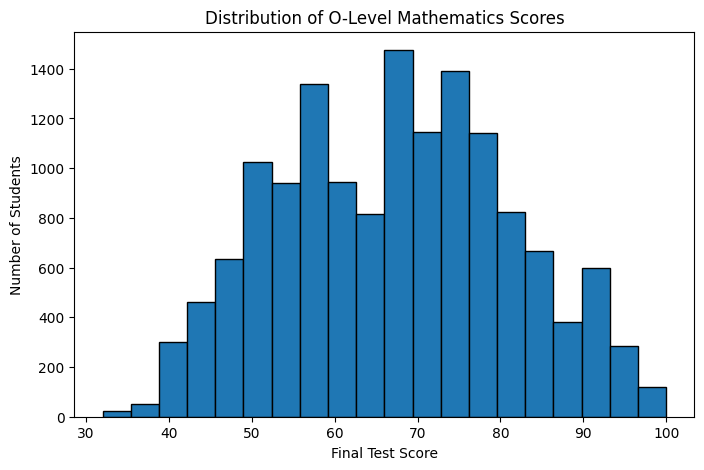

In [200]:
#Visualize the distribution of final_test
plt.figure(figsize=(8,5))
plt.hist(
    df_clean["final_test"].dropna(),
    bins=20,
    edgecolor="black"
)

plt.xlabel("Final Test Score")
plt.ylabel("Number of Students")
plt.title("Distribution of O-Level Mathematics Scores")

# Save as PNG
plt.savefig(
    charts_folder / "Distribution_of_O-LevelMathScores.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

##### **Step 2. Bi-variate EDA: Investigate the relationship of the Numerical variables with the target variable**

In [202]:
# View the correlations of the Numerical variables with final_test using the Pearson correlation (8 variables)
numeric_features = [
    "final_test",
    "hours_per_week",
    "attendance_rate",
    "sleep_duration",
    "age",
    "number_of_siblings",
    "n_male",
    "n_female"
]

correlation = (
    df_clean[numeric_features]
    .corr()["final_test"]
    .sort_values(ascending=False)
)

correlation

final_test            1.000000
attendance_rate       0.345990
sleep_duration        0.325022
age                   0.003801
n_male               -0.148900
hours_per_week       -0.150560
n_female             -0.173856
number_of_siblings   -0.360987
Name: final_test, dtype: float64

##### <font color='blue'>**KEY OBSERVATIONS OF NUMERICAL VARIABLES**</font><br>

**1. MODERATE Positive Relationship** </br>
- attendance_rate
- sleep_duration
  
**2. MODERATE Negative Relationship** </br>
- number_of_siblings

**3. Weak Negative Relationship** </br>
- n_male
- hours_per_week
- n_female

**4. Almost Negligible Relationship** </br>
- age

##### **Step 3. Bi-variate EDA: Investigate the relationship of the Categorical variables with the target variable**

In [203]:
# Compare final_test performance across categorical variables (6 variables)
categorical_features = [
    "direct_admission",
    "CCA",
    "learning_style",
    "gender",
    "tuition",
    "mode_of_transport"
]

for col in categorical_features:
    print(f"\n--- {col} ---")

    display(
        df_clean.groupby(col)["final_test"]
        .agg(["count", "mean", "median", "std"])
        .round(2)
        .sort_values("mean", ascending=False)
    )


--- direct_admission ---


,count,mean,median,std
direct_admission,,,,
Yes,4284,72.48,76.0,14.02
No,10275,64.98,64.0,13.35



--- CCA ---


,count,mean,median,std
CCA,,,,
None,3617,76.75,78.0,12.22
Arts,3594,64.10,63.0,13.16
Sports,3641,64.08,64.0,13.02
Clubs,3707,63.91,63.0,12.99



--- learning_style ---


...

,count,mean,median,std
gender,,,,
Male,7301,67.34,68.0,13.90
Female,7258,67.03,68.0,14.05



--- tuition ---


,count,mean,median,std
tuition,,,,
Yes,8252,70.48,71.0,12.86
No,6307,62.88,61.0,14.21



--- mode_of_transport ---


,count,mean,median,std
mode_of_transport,,,,
private transport,5815,67.27,68.0,13.99
walk,2929,67.18,68.0,13.99
public transport,5815,67.12,68.0,13.95


##### <font color='blue'>**KEY OBSERVATIONS OF CATEGORICAL VARIABLES**</font><br>

1. Substantial differences of the Mean values
- CCA | None: 76.75 vs ~64 for other groups | Difference of ~12.75
- tuition | Yes: 70.48 vs No: 62.88 | Difference of 7.6
- learning_style | Visual: 71.61 vs Auditory: 63.92 | Difference of 7.69
- direct_admission | Yes: 72.48 vs No: 64.98 | Difference of 7.5

  
2. No material differences of the Mean values (less than 0.31)
- gender
- mode_of_transport

##### **Step 4. Multi-variate EDA: Investigate the relationship of the strong predictor Numerical variables with the target variable and other numerical variables**

##### A. attendance_rate (r = 0.346)

In [204]:
attendance_analysis = (
    df_clean
    .groupby("attendance_rate")
    .agg(
        students=("student_id", "count"),
        mean_score=("final_test", "mean")
    )
    .round(2)
)

attendance_analysis

,students,mean_score
attendance_rate,,
40.0,7,42.80
41.0,7,42.43
42.0,4,42.00
43.0,9,43.00
44.0,9,41.00
...,...,...
96.0,1348,68.71
97.0,1408,68.97
98.0,1343,68.68


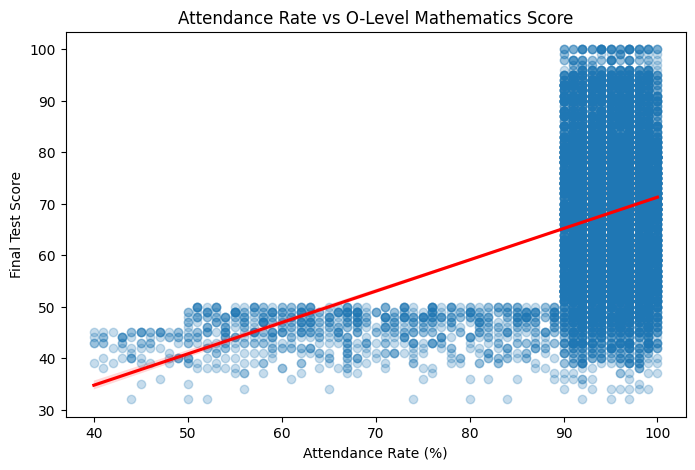

In [205]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=df_clean,
    x="attendance_rate",
    y="final_test",
    scatter_kws={"alpha": 0.25},
    line_kws={"color": "red"}
)

plt.xlabel("Attendance Rate (%)")
plt.ylabel("Final Test Score")
plt.title("Attendance Rate vs O-Level Mathematics Score")

# Save as PNG
plt.savefig(
    charts_folder / "AttendanceRate_vs_O-LevelMathScores.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

##### <font color='blue'>**KEY OBSERVATIONS OF attendance_rate**</font><br>

1. Below roughly 90% attendance, scores are heavily concentrated around 32–50. </br>
2. At roughly 90–100% attendance, scores have a much wider range, extending to 100. </br>
3. Lower attendance is strongly associated with low mathematics performance, while high attendance appears necessary but not sufficient for high performance. </br>
4. A student with 98% attendance can still score 40. But students with very low attendance almost never appear among the high scorers. </br>

##### B. sleep_duration (r = 0.325)

In [206]:
df_clean["sleep_lessthan6hrs"] = df_clean["sleep_duration"] <= 6

df_clean.groupby("sleep_lessthan6hrs").agg(
    students=("student_id", "count"),
    mean_score=("final_test", "mean"),
    mean_study_hours=("hours_per_week", "mean"),
    mean_attendance=("attendance_rate", "mean")
).round(2)

,students,mean_score,mean_study_hours,mean_attendance
sleep_lessthan6hrs,,,,
False,14416,68.09,10.43,94.65
True,584,44.99,7.57,59.65


##### <font color='blue'>**KEY OBSERVATIONS OF sleep_duration**</font><br>

1. There are 14,416 students who sleep 7 hours and more (96.1%). </br>
2. There are 584 students who sleep 6 hours and less (3.89%). </br>
3. Students sleeping 6 hours or less show a distinct at-risk behavioural profile, characterized by substantially lower attendance (59.65%), fewer weekly study hours (7.57), and lower average mathematics performance (44.99). These relationships are associative and do not establish causality. </br>

In [207]:
df_clean.head(20)

,index,number_of_siblings,direct_admission,CCA,learning_style,student_id,gender,tuition,final_test,n_male,n_female,age,hours_per_week,attendance_rate,sleep_time,wake_time,mode_of_transport,bag_color,sleep_duration,sleep_lessthan6hrs
0,0,0,Yes,Sports,Visual,ACN2BE,Female,No,69.0,14.0,2.0,16.0,10.0,91.0,22:00,6:00,private transport,yellow,8.0,False
1,1,2,No,Sports,Auditory,FGXIIZ,Female,No,47.0,4.0,19.0,16.0,7.0,94.0,22:30,6:30,private transport,green,8.0,False
2,2,0,Yes,None,Visual,B9AI9F,Male,No,85.0,14.0,2.0,15.0,8.0,92.0,22:30,6:30,private transport,white,8.0,False
3,3,1,No,Clubs,Auditory,FEVM1T,Female,Yes,64.0,2.0,20.0,15.0,18.0,NaN,21:00,5:00,public transport,yellow,8.0,False
4,4,0,No,Sports,Auditory,AXZN2E,Male,No,66.0,24.0,3.0,16.0,7.0,95.0,21:30,5:30,public transport,yellow,8.0,False
5,5,0,No,Arts,Visual,BA6R14,Female,No,57.0,9.0,12.0,15.0,11.0,96.0,22:30,6:30,private transport,red,8.0,False
6,6,2,Yes,None,Visual,D5WGTI,Male,No,69.0,12.0,3.0,16.0,15.0,93.0,21:30,5:30,public transport,green,8.0,False
7,7,0,No,Sports,Visual,HTP8CW,Male,No,76.0,20.0,2.0,15.0,3.0,97.0,21:00,5:00,public transport,green,8.0,False
8,8,0,No,Arts,Auditory,U3YRTC,Male,No,57.0,20.0,7.0,15.0,15.0,98.0,22:00,6:00,private transport,red,8.0,False
9,9,2,No,Arts,Auditory,3MOMA6,Male,Yes,60.0,13.0,9.0,16.0,16.0,NaN,22:30,6:30,private transport,green,8.0,False


##### C. hours_per_week (r = -0.150) | study hours per week 

In [208]:
study_analysis = (
    df_clean
    .groupby("hours_per_week")
    .agg(
        students=("student_id", "count"),
        mean_score=("final_test", "mean"),
        median_score=("final_test", "median"),
        mean_attendance=("attendance_rate", "mean"),
        mean_sleep=("sleep_duration", "mean")
    )
    .round(2)
)

study_analysis

,students,mean_score,median_score,mean_attendance,mean_sleep
hours_per_week,,,,,
0.0,55,47.47,45.0,84.45,7.18
1.0,134,45.01,45.0,81.09,6.99
2.0,128,46.43,47.0,84.03,7.21
3.0,135,46.83,46.0,83.10,7.06
4.0,149,47.04,47.0,83.80,7.19
5.0,879,70.84,75.0,92.82,7.82
6.0,1540,72.60,77.0,93.65,7.88
7.0,1654,72.88,77.0,93.52,7.88
8.0,1671,72.49,76.0,93.59,7.87


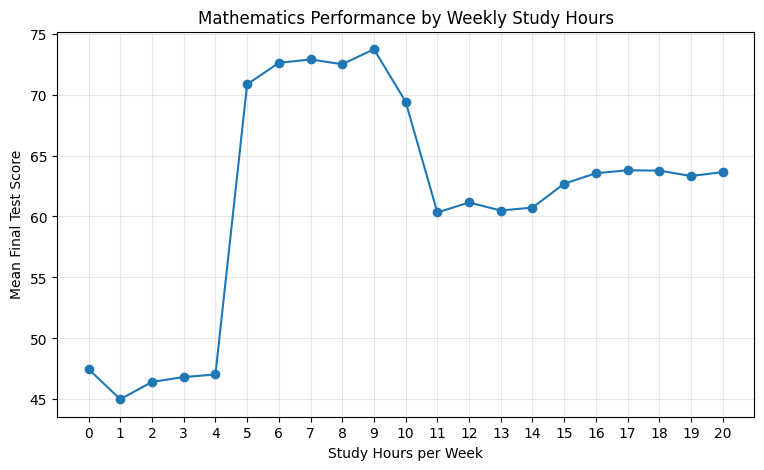

In [209]:
plt.figure(figsize=(9, 5))

plt.plot(
    study_analysis.index,
    study_analysis["mean_score"],
    marker="o"
)

plt.xlabel("Study Hours per Week")
plt.ylabel("Mean Final Test Score")
plt.title("Mathematics Performance by Weekly Study Hours")

plt.xticks(range(0, 21))
plt.grid(alpha=0.3)

# Save as PNG
plt.savefig(
    charts_folder / "WeeklyStudyHours_vs_O-LevelMathScores.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

##### <font color='blue'>**KEY OBSERVATIONS OF hours_per_week**</font><br>

1. Summary of study hours vs final_test
- 0–4 hours       → ~45–47
- 5–9 hours       → ~71–74
- 10 hours        → ~69
- 11–20 hours     → ~60–64
  
2. Students studying around 5–9 hours per week have the highest average performance.

##### D. number_of_siblings (r = -0.361)

In [211]:
siblings_analysis = (
    df_clean
    .groupby("number_of_siblings")
    .agg(
        students=("student_id", "count"),
        mean_score=("final_test", "mean"),
        median_score=("final_test", "median"),
        mean_attendance=("attendance_rate", "mean"),
        mean_study_hours=("hours_per_week", "mean"),
        mean_sleep=("sleep_duration", "mean")
    )
    .round(2)
)

siblings_analysis

,students,mean_score,median_score,mean_attendance,mean_study_hours,mean_sleep
number_of_siblings,,,,,,
0,5167,75.96,76.0,95.00,9.89,7.96
1,6346,61.86,59.0,92.21,10.35,7.77
2,3487,63.88,67.0,92.72,10.90,7.81


##### <font color='blue'>**KEY OBSERVATIONS OF number_of_siblings**</font><br>

1. Summary of number_of_siblings vs final_test
- 0 siblings → 75.96
- 1 sibling  → 61.86
- 2 siblings → 63.88
  
2. Students with no siblings showed substantially higher average mathematics scores than students with one or two siblings.

##### **Step 5. Calculate the correlation matrix among the numerical predictors**

In [212]:
#Calculate the correlation matrix among the numerical predictors
key_numeric = [
    "final_test",
    "attendance_rate",
    "sleep_duration",
    "hours_per_week",
    "number_of_siblings"
]

key_corr = df_clean[key_numeric].corr().round(2)

key_corr

,final_test,attendance_rate,sleep_duration,hours_per_week,number_of_siblings
final_test,1.00,0.35,0.33,-0.15,-0.36
attendance_rate,0.35,1.00,0.89,0.14,-0.12
sleep_duration,0.33,0.89,1.00,0.12,-0.11
hours_per_week,-0.15,0.14,0.12,1.00,0.08
number_of_siblings,-0.36,-0.12,-0.11,0.08,1.00


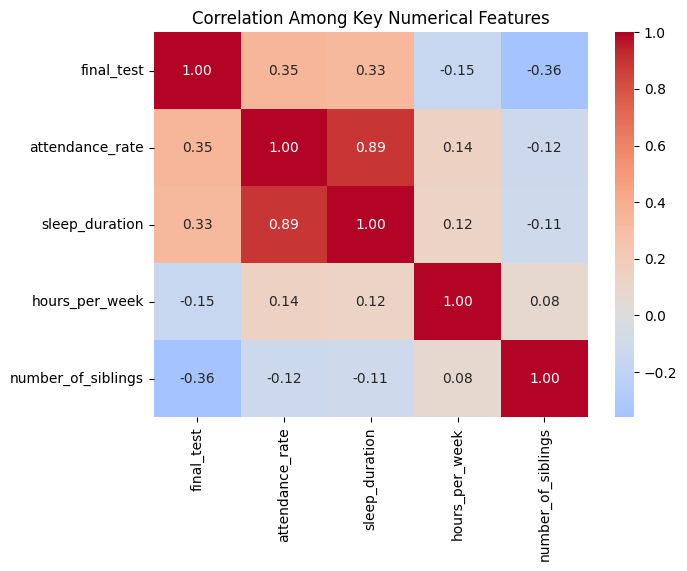

In [213]:
# Visualise the correlation
plt.figure(figsize=(7, 5))

sns.heatmap(
    key_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Among Key Numerical Features")

# Save as PNG
plt.savefig(
    charts_folder / "Correlation_of_NumericalFeatures.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

##### <font color='blue'>**KEY OBSERVATIONS**</font><br>

1. There is a very strong correlation between attendance_rate and sleep_duration at r = 0.89. This suggests that sleep and attendance may belong to the same underlying student-behaviour pattern rather than being independent effects. </br>
2. Sleep duration is positively associated with mathematics performance; however, its strong correlation with attendance (r = 0.89) suggests that the two variables may capture overlapping behavioural patterns. </br>

##### **Step 6. Multi-variate EDA: Investigate the relationship of the strong predictor Categorical variables with other categorical variables**

In [214]:
pd.crosstab(
    df_clean["CCA"],
    df_clean["direct_admission"],
    normalize="index"
).round(3)

direct_admission,No,Yes
CCA,,
Arts,0.735,0.265
Clubs,0.734,0.266
None,0.617,0.383
Sports,0.734,0.266


In [215]:
pd.crosstab(
    df_clean["CCA"],
    df_clean["tuition"],
    normalize="index"
).round(3)

tuition,No,Yes
CCA,,
Arts,0.463,0.537
Clubs,0.467,0.533
None,0.350,0.650
Sports,0.452,0.548


In [216]:
pd.crosstab(
    df_clean["CCA"],
    df_clean["learning_style"],
    normalize="index"
).round(3)

learning_style,Auditory,Visual
CCA,,
Arts,0.617,0.383
Clubs,0.601,0.399
None,0.471,0.529
Sports,0.613,0.387


##### <font color='blue'>**KEY OBSERVATIONS**</font><br>

1. CCA was selected for further multivariate investigation because it showed a pronounced difference in mathematics performance.
- Arts, Sports and Clubs were almost identical at around 64, while students with no CCA averaged almost 77 in the mean score - a difference of 12.7 points.
- Crosstab analysis was then used to examine whether the CCA=None group also differed systematically across other categorical characteristics.
 
2. Students with no CCA are disproportionately direct-admission students. </br>
- Direct admission = Yes → mean score 72.48
- Direct admission = No  → mean score 64.98
- No CCA → mean score 76.75
- CCA    → ~64

Therefore, some of the apparent No-CCA advantage may overlap with direct-admission status. </br>

3. Students without CCA are substantially more likely to receive tuition. </br>
- Tuition Yes → 70.48
- Tuition No  → 62.88

Therefore, the apparent No CCA → higher score relationship may also partly reflect higher tuition participation. Note that this is association, not causation.

4. The No-CCA group is also substantially more likely to be classified as Visual learners.
- Visual   → mean score 71.61
- Auditory → mean score 63.92

##### **Step 7. Explore class size and gender composition in the class**

In [217]:
# Compute the class size of each student
df_clean["class_size"] = (
    df_clean["n_male"] + df_clean["n_female"]
)

df_clean.head(20)

,index,number_of_siblings,direct_admission,CCA,learning_style,student_id,gender,tuition,final_test,n_male,...,age,hours_per_week,attendance_rate,sleep_time,wake_time,mode_of_transport,bag_color,sleep_duration,sleep_lessthan6hrs,class_size
0,0,0,Yes,Sports,Visual,ACN2BE,Female,No,69.0,14.0,...,16.0,10.0,91.0,22:00,6:00,private transport,yellow,8.0,False,16.0
1,1,2,No,Sports,Auditory,FGXIIZ,Female,No,47.0,4.0,...,16.0,7.0,94.0,22:30,6:30,private transport,green,8.0,False,23.0
2,2,0,Yes,None,Visual,B9AI9F,Male,No,85.0,14.0,...,15.0,8.0,92.0,22:30,6:30,private transport,white,8.0,False,16.0
3,3,1,No,Clubs,Auditory,FEVM1T,Female,Yes,64.0,2.0,...,15.0,18.0,NaN,21:00,5:00,public transport,yellow,8.0,False,22.0
4,4,0,No,Sports,Auditory,AXZN2E,Male,No,66.0,24.0,...,16.0,7.0,95.0,21:30,5:30,public transport,yellow,8.0,False,27.0
5,5,0,No,Arts,Visual,BA6R14,Female,No,57.0,9.0,...,15.0,11.0,96.0,22:30,6:30,private transport,red,8.0,False,21.0
6,6,2,Yes,None,Visual,D5WGTI,Male,No,69.0,12.0,...,16.0,15.0,93.0,21:30,5:30,public transport,green,8.0,False,15.0
7,7,0,No,Sports,Visual,HTP8CW,Male,No,76.0,20.0,...,15.0,3.0,97.0,21:00,5:00,public transport,green,8.0,False,22.0
8,8,0,No,Arts,Auditory,U3YRTC,Male,No,57.0,20.0,...,15.0,15.0,98.0,22:00,6:00,private transport,red,8.0,False,27.0
9,9,2,No,Arts,Auditory,3MOMA6,Male,Yes,60.0,13.0,...,16.0,16.0,NaN,22:30,6:30,private transport,green,8.0,False,22.0


In [218]:
# View the unique combinations of n_female, n_male and class_size
class_size_combinations = (
    df_clean
    .groupby(
        ["n_female", "n_male", "class_size"]
    )
    .size()
    .reset_index(name="student_count")
    .sort_values(
        ["class_size", "n_female", "n_male"]
    )
)

#Export class_size_combinations to CSV file and save inside data folder
class_size_combinations.to_csv(
    output_folder / "class_size_combinations.csv",
    index=False
)

In [219]:
# Examine relationships with class_size
df_clean[
    ["n_male", "n_female", "class_size", "final_test"]
].corr().round(3)

,n_male,n_female,class_size,final_test
n_male,1.000,-0.795,0.297,-0.149
n_female,-0.795,1.000,0.343,-0.174
class_size,0.297,0.343,1.000,-0.504
final_test,-0.149,-0.174,-0.504,1.000


In [220]:
# View summary statistics
df_clean["class_size"].describe()

count    15000.000000
mean        22.781867
std          4.230872
min         14.000000
25%         20.000000
50%         22.000000
75%         27.000000
max         31.000000
Name: class_size, dtype: float64

In [221]:
# Count the number of records per value
df_clean["class_size"].value_counts().sort_index()

class_size
14.0     173
15.0     331
16.0     478
17.0     968
18.0     517
19.0     907
20.0    1158
21.0    1610
22.0    1842
23.0     948
24.0    1017
25.0     897
26.0     197
27.0    1340
28.0    1138
29.0     194
30.0    1060
31.0     225
Name: count, dtype: int64

In [222]:
# Compute the proportion of female classmates
df_clean["female_ratio"] = (
    df_clean["n_female"] / df_clean["class_size"]
)

df_clean.head(20)

,index,number_of_siblings,direct_admission,CCA,learning_style,student_id,gender,tuition,final_test,n_male,...,hours_per_week,attendance_rate,sleep_time,wake_time,mode_of_transport,bag_color,sleep_duration,sleep_lessthan6hrs,class_size,female_ratio
0,0,0,Yes,Sports,Visual,ACN2BE,Female,No,69.0,14.0,...,10.0,91.0,22:00,6:00,private transport,yellow,8.0,False,16.0,0.125000
1,1,2,No,Sports,Auditory,FGXIIZ,Female,No,47.0,4.0,...,7.0,94.0,22:30,6:30,private transport,green,8.0,False,23.0,0.826087
2,2,0,Yes,None,Visual,B9AI9F,Male,No,85.0,14.0,...,8.0,92.0,22:30,6:30,private transport,white,8.0,False,16.0,0.125000
3,3,1,No,Clubs,Auditory,FEVM1T,Female,Yes,64.0,2.0,...,18.0,NaN,21:00,5:00,public transport,yellow,8.0,False,22.0,0.909091
4,4,0,No,Sports,Auditory,AXZN2E,Male,No,66.0,24.0,...,7.0,95.0,21:30,5:30,public transport,yellow,8.0,False,27.0,0.111111
5,5,0,No,Arts,Visual,BA6R14,Female,No,57.0,9.0,...,11.0,96.0,22:30,6:30,private transport,red,8.0,False,21.0,0.571429
6,6,2,Yes,None,Visual,D5WGTI,Male,No,69.0,12.0,...,15.0,93.0,21:30,5:30,public transport,green,8.0,False,15.0,0.200000
7,7,0,No,Sports,Visual,HTP8CW,Male,No,76.0,20.0,...,3.0,97.0,21:00,5:00,public transport,green,8.0,False,22.0,0.090909
8,8,0,No,Arts,Auditory,U3YRTC,Male,No,57.0,20.0,...,15.0,98.0,22:00,6:00,private transport,red,8.0,False,27.0,0.259259
9,9,2,No,Arts,Auditory,3MOMA6,Male,Yes,60.0,13.0,...,16.0,NaN,22:30,6:30,private transport,green,8.0,False,22.0,0.409091


In [223]:
# Examine relationships
df_clean[
    ["n_male", "n_female", "class_size",
     "female_ratio", "final_test"]
].corr().round(3)

,n_male,n_female,class_size,female_ratio,final_test
n_male,1.000,-0.795,0.297,-0.901,-0.149
n_female,-0.795,1.000,0.343,0.954,-0.174
class_size,0.297,0.343,1.000,0.106,-0.504
female_ratio,-0.901,0.954,0.106,1.000,-0.053
final_test,-0.149,-0.174,-0.504,-0.053,1.000


In [224]:
# Multi-variate EDA: Investigate the relationship of the strong predictor Numerical variables with the target variable and other numerical variables**

class_size_analysis = (
    df_clean
    .groupby("class_size")
    .agg(
        students=("student_id", "count"),
        mean_score=("final_test", "mean"),
        median_score=("final_test", "median"),
        mean_attendance=("attendance_rate", "mean"),
        mean_study_hours=("hours_per_week", "mean"),
        mean_sleep=("sleep_duration", "mean"),
        mean_siblings=("number_of_siblings", "mean"),
    )
    .round(2)
)

class_size_analysis

,students,mean_score,median_score,mean_attendance,mean_study_hours,mean_sleep,mean_siblings
class_size,,,,,,,
14.0,173,76.53,77.0,94.84,9.82,7.98,2.00
15.0,331,75.32,75.0,94.96,10.15,7.96,0.57
16.0,478,72.45,71.0,95.17,10.68,7.98,0.49
17.0,968,82.65,81.0,94.93,7.91,7.97,1.13
18.0,517,75.44,79.0,94.72,9.10,7.96,1.03
19.0,907,72.62,72.0,94.54,10.72,7.94,1.32
20.0,1158,68.81,71.0,94.98,11.11,7.97,0.83
21.0,1610,75.41,74.0,94.95,10.22,7.96,0.60
22.0,1842,65.41,64.0,93.63,10.87,7.86,1.05


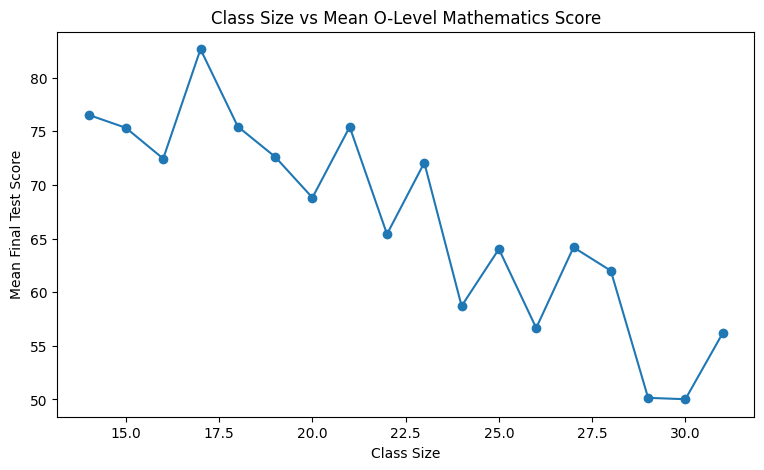

In [225]:
# Visualise the correlation
plt.figure(figsize=(9, 5))

plt.plot(
    class_size_analysis.index,
    class_size_analysis["mean_score"],
    marker="o"
)

plt.xlabel("Class Size")
plt.ylabel("Mean Final Test Score")
plt.title("Class Size vs Mean O-Level Mathematics Score")

# Save as PNG
plt.savefig(
    charts_folder / "ClassSize_vs_Mean_O-LevelMathScores.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [226]:
#Calculate the correlation matrix among the numerical predictors
df_clean[
    [
        "class_size",
        "attendance_rate",
        "sleep_duration",
        "hours_per_week",
        "number_of_siblings",
        "final_test"
    ]
].corr().round(3)

,class_size,attendance_rate,sleep_duration,hours_per_week,number_of_siblings,final_test
class_size,1.000,-0.156,-0.149,0.080,-0.078,-0.504
attendance_rate,-0.156,1.000,0.886,0.143,-0.121,0.346
sleep_duration,-0.149,0.886,1.000,0.123,-0.106,0.325
hours_per_week,0.080,0.143,0.123,1.000,0.084,-0.151
number_of_siblings,-0.078,-0.121,-0.106,0.084,1.000,-0.361
final_test,-0.504,0.346,0.325,-0.151,-0.361,1.000


In [227]:
# Manual Assignment: Group class_size into bands
df_clean["class_size_group"] = pd.cut(
    df_clean["class_size"],
    bins=[13, 19, 24, 31],
    labels=["Small (14-19)", "Medium (20-24)", "Large (25-31)"]
)

class_size_group_analysis = (
    df_clean
    .groupby("class_size_group", observed=True)
    .agg(
        students=("student_id", "count"),
        mean_score=("final_test", "mean"),
        median_score=("final_test", "median"),
        mean_attendance=("attendance_rate", "mean"),
        mean_study_hours=("hours_per_week", "mean"),
        mean_sleep=("sleep_duration", "mean")
    )
    .round(2)
)

class_size_group_analysis

,students,mean_score,median_score,mean_attendance,mean_study_hours,mean_sleep
class_size_group,,,,,,
Small (14-19),3374,76.37,77.0,94.83,9.56,7.96
Medium (20-24),6575,68.37,69.0,93.29,10.36,7.85
Large (25-31),5051,59.50,58.0,92.26,10.78,7.77


In [228]:
# Create data-driven class_size bands using tertiles
# The pandas.qcut function is a quantile-based discretization tool that splits numerical data into equal-sized buckets based on rank or sample quantiles
df_clean["class_size_tertile"] = pd.qcut(
    df_clean["class_size"],
    q=3,
    duplicates="drop"
)

tertile_analysis = (
    df_clean
    .groupby("class_size_tertile", observed=True)
    .agg(
        students=("student_id", "count"),
        min_size=("class_size", "min"),
        max_size=("class_size", "max"),
        mean_size=("class_size", "mean"),
        mean_score=("final_test", "mean"),
        median_score=("final_test", "median"),
        mean_attendance=("attendance_rate", "mean"),
        mean_study_hours=("hours_per_week", "mean"),
        mean_sleep=("sleep_duration", "mean")
    )
    .round(2)
)

tertile_analysis

,students,min_size,max_size,mean_size,mean_score,median_score,mean_attendance,mean_study_hours,mean_sleep
class_size_tertile,,,,,,,,,
"(13.999, 21.0]",6142,14.0,21.0,18.72,74.69,75.0,94.89,10.02,7.96
"(21.0, 25.0]",4704,22.0,25.0,23.21,65.05,65.0,91.87,9.99,7.75
"(25.0, 31.0]",4154,26.0,31.0,28.30,58.53,58.0,92.53,11.14,7.79


In [229]:
# Final: Assign descriptive labels to the class_size tertiles
df_clean["class_size_tertile"] = pd.qcut(
    df_clean["class_size"],
    q=3,
    labels=[
        "Lower (14-21)",
        "Middle (22-25)",
        "Higher (26-31)"
    ],
    duplicates="drop"
)

# Verify
df_clean["class_size_tertile"].value_counts().sort_index()

class_size_tertile
Lower (14-21)     6142
Middle (22-25)    4704
Higher (26-31)    4154
Name: count, dtype: int64

In [230]:
#Export df_clean to CSV file and save inside data folder
df_clean.to_csv(
    output_folder / "df_clean.csv",
    index=False
)

##### <font color='blue'>**KEY OBSERVATIONS of class_size**</font><br>

**1. MODERATE-TO-STRONG NEGATIVE Relationship** </br>
- class_size (r = -0.504)

The number of classmates appears much more relevant than whether those classmates are male or female. </br>

Larger class sizes are associated with lower mathematics scores overall, although the relationship is not strictly linear across every class size.  </br>
There are several jumps: </br>
- 16 → 17: 72.45 → 82.65
- 20 → 21: 68.81 → 75.41
- 22 → 23: 65.41 → 72.07
- 24 → 25: 58.71 → 64.02
- 26 → 27: 56.66 → 64.18

The class-size relationship with performance doesn't appear to be simply a reflection of the other variables. </br>
For example, class size=31:
- mean score = 56.18
- mean attendance = 95.00%
- mean study hours = 11.79
- mean sleep = 7.96 hours </br>


Despite apparently strong attendance, study hours and sleep, this group still has a relatively low mean score. </br>

The apparent relationships between the numbers of male/female classmates and mathematics performance are better explained by overall class size than by gender composition. </br>

To examine this relationship without manually selecting class-size thresholds, students were grouped into tertiles based on the observed class-size distribution. </br>
- Mean mathematics scores declined substantially across the class-size groups: 74.69 for lower class sizes (14–21), 65.05 for middle class sizes (22–25), and 58.53 for higher class sizes (26–31). This represents a 16.16-point difference between the lower and higher class-size groups. </br>
- The largest-class group also reported higher average weekly study hours (11.14 hours) than the smallest-class group (10.02 hours), despite considerably lower mathematics scores. </br>
- The results suggest that class size is an important predictor of mathematics performance in this dataset. However, these associations should not be interpreted as evidence that larger class sizes directly cause poorer examination performance. </br>

**2. Weak Negative Relationship** </br>
- n_male
- n_female

**3. Almost Negligible Relationship** </br>
- female_ratio

### <font color = green> **PART C: FEATURE SELECTION & MODEL PREPARATION**</br></font>

How well can students' O-Level Mathematics scores be predicted from the available student, behavioural and educational characteristics, and which factors contribute most strongly to those predictions?

##### **Step 1. Create the modelling dataset**

In [231]:
# Load df_clean
df_model = pd.read_csv(f"{output_folder}/df_clean.csv")

In [232]:
# Create modelling dataset
# Remove records where the target variable final_test is missing (441 records)

df_model = (
    df_clean
    .dropna(subset=["final_test"])
    .copy()
)

print("Rows in cleaned dataset:", len(df_clean))
print("Rows available for modelling:", len(df_model))
print("Missing final_test:", df_model["final_test"].isna().sum())

Rows in cleaned dataset: 15000
Rows available for modelling: 14559
Missing final_test: 0


In [233]:
df_model

,index,number_of_siblings,direct_admission,CCA,learning_style,student_id,gender,tuition,final_test,n_male,...,sleep_time,wake_time,mode_of_transport,bag_color,sleep_duration,sleep_lessthan6hrs,class_size,female_ratio,class_size_group,class_size_tertile
0,0,0,Yes,Sports,Visual,ACN2BE,Female,No,69.0,14.0,...,22:00,6:00,private transport,yellow,8.0,False,16.0,0.125000,Small (14-19),Lower (14-21)
1,1,2,No,Sports,Auditory,FGXIIZ,Female,No,47.0,4.0,...,22:30,6:30,private transport,green,8.0,False,23.0,0.826087,Medium (20-24),Middle (22-25)
2,2,0,Yes,None,Visual,B9AI9F,Male,No,85.0,14.0,...,22:30,6:30,private transport,white,8.0,False,16.0,0.125000,Small (14-19),Lower (14-21)
3,3,1,No,Clubs,Auditory,FEVM1T,Female,Yes,64.0,2.0,...,21:00,5:00,public transport,yellow,8.0,False,22.0,0.909091,Medium (20-24),Middle (22-25)
4,4,0,No,Sports,Auditory,AXZN2E,Male,No,66.0,24.0,...,21:30,5:30,public transport,yellow,8.0,False,27.0,0.111111,Large (25-31),Higher (26-31)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15895,15895,1,No,Clubs,Visual,XPECN2,Female,No,56.0,12.0,...,22:00,6:00,private transport,black,8.0,False,26.0,0.538462,Large (25-31),Higher (26-31)
15896,15896,1,Yes,None,Auditory,7AMC7S,Male,Yes,85.0,17.0,...,22:30,6:30,private transport,white,8.0,False,22.0,0.227273,Medium (20-24),Middle (22-25)
15897,15897,1,Yes,Sports,Auditory,XKZ6VN,Female,Yes,76.0,7.0,...,23:00,7:00,walk,red,8.0,False,17.0,0.588235,Small (14-19),Lower (14-21)
15898,15898,1,No,Clubs,Visual,2OU4UQ,Male,Yes,45.0,18.0,...,23:00,7:00,walk,yellow,8.0,False,30.0,0.400000,Large (25-31),Higher (26-31)


In [234]:
df_model.info()

<class 'pandas.DataFrame'>
Index: 14559 entries, 0 to 15899
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   index               14559 non-null  int64   
 1   number_of_siblings  14559 non-null  int64   
 2   direct_admission    14559 non-null  str     
 3   CCA                 14559 non-null  str     
 4   learning_style      14559 non-null  str     
 5   student_id          14559 non-null  str     
 6   gender              14559 non-null  str     
 7   tuition             14559 non-null  str     
 8   final_test          14559 non-null  float64 
 9   n_male              14559 non-null  float64 
 10  n_female            14559 non-null  float64 
 11  age                 14139 non-null  float64 
 12  hours_per_week      14559 non-null  float64 
 13  attendance_rate     13890 non-null  float64 
 14  sleep_time          14559 non-null  str     
 15  wake_time           14559 non-null  str     
 16  mo

**<font color='blue'>Target Variable Preparation**</font> </br>
- The cleaned dataset contains 15,000 unique students (df_clean).  </br>
- Of these, 441 students have no recorded O-Level Mathematics examination score (final_test).  </br>
- As the target variable should not be imputed for supervised learning, these records were excluded from model development.  </br>
- This leaves 14,559 students available for modelling (df_model). </br>
- Missing values: age (420 records); attendance_rate (669 records)

##### **Step 2. Define the target variable**

In [235]:
# Define the target variable: O-Level Mathematics examination score

target = "final_test"

y = df_model[target]

y.describe()

count    14559.000000
mean        67.188474
std         13.976515
min         32.000000
25%         56.000000
50%         68.000000
75%         78.000000
max        100.000000
Name: final_test, dtype: float64

##### **Step 3. Define candidate predictors**

##### A. Verify relevance of age as a candidate predictor  
Its correlation with final_test was essentially zero (r ≈ 0.004) after cleaning. However, age has only two valid values—15 and 16. To compare their score distributions before deciding whether to remove it. </br>

In [236]:
age_analysis = (
    df_model
    .groupby("age")
    .agg(
        students=("student_id", "count"),
        mean_score=("final_test", "mean"),
        median_score=("final_test", "median"),
        std_score=("final_test", "std")
    )
    .round(2)
)

age_analysis

,students,mean_score,median_score,std_score
age,,,,
15.0,7057,67.16,68.0,13.82
16.0,7082,67.27,68.0,14.11


In [237]:
age_mean_score = df_model.groupby("age")["final_test"].mean()

print(
    "Difference in mean final_test score:",
    round(age_mean_score.max() - age_mean_score.min(), 2)
)

Difference in mean final_test score: 0.11


##### B. Numerical predictors (Total: 6)

In [238]:
numeric_features = [
    "class_size",
    "number_of_siblings",
    "attendance_rate",
    "sleep_duration",
    "hours_per_week"
]

##### C. Categorical predictors (Total: 4)

In [239]:
categorical_features = [
    "direct_admission",
    "CCA",
    "learning_style",
    "tuition"
]

##### D. Combine all predictors to build the modelling dataset X (Total: 10)

In [240]:
selected_features = numeric_features + categorical_features

#Modelling Dataset
X = df_model[selected_features].copy()

print("Number of predictors:", len(selected_features))
print("\nSelected predictors:")
print(selected_features)

Number of predictors: 9

Selected predictors:
['class_size', 'number_of_siblings', 'attendance_rate', 'sleep_duration', 'hours_per_week', 'direct_admission', 'CCA', 'learning_style', 'tuition']


In [241]:
#View the modelling dataset
X.head(20)

,class_size,number_of_siblings,attendance_rate,sleep_duration,hours_per_week,direct_admission,CCA,learning_style,tuition
0,16.0,0,91.0,8.0,10.0,Yes,Sports,Visual,No
1,23.0,2,94.0,8.0,7.0,No,Sports,Auditory,No
2,16.0,0,92.0,8.0,8.0,Yes,None,Visual,No
3,22.0,1,NaN,8.0,18.0,No,Clubs,Auditory,Yes
4,27.0,0,95.0,8.0,7.0,No,Sports,Auditory,No
5,21.0,0,96.0,8.0,11.0,No,Arts,Visual,No
6,15.0,2,93.0,8.0,15.0,Yes,None,Visual,No
7,22.0,0,97.0,8.0,3.0,No,Sports,Visual,No
8,27.0,0,98.0,8.0,15.0,No,Arts,Auditory,No
9,22.0,2,NaN,8.0,16.0,No,Arts,Auditory,Yes


**<font color='blue'>EXCLUDED from the Candidate Predictor List**</font> </br>

A. Numerical Variables (Total: 7) </br>

1. index - Original row/index identifier
2. age - Negligible association with final_test (r ≈ 0.004). Mean scores for ages 15 and 16 differed by only 0.11 points, with identical median scores. Also contains missing values (420 records).
3. n_male - Replaced by more meaningful engineered variable class_size
4. n_female - Replaced by more meaningful engineered variable class_size
5. female_ratio - Weak relationship with target and highly derived from gender-count variables
6. sleep_lessthan6hrs - Derived directly from sleep_duration; redundant variable
7. class_size_tertile - Derived directly from continuous variable class_size


B. Categorical Variables (Total: 6) </br>

1. student_id - Unique identifier; no meaningful predictive interpretation
2. bag_color - No defensible relationship with academic performance established
3. sleep_time - Represented more analytically by engineered variable sleep_duration
4. wake_time - Represented more analytically by engineered variable sleep_duration
5. gender - No material differences in the mean final_test scores across gender categories
6. mode_of_transport - No material differences in mean final_test scores across transport categories

##### **Step 4. Check the modelling features before splitting**

##### A. Check dimensions and data types

In [242]:
X.info()

<class 'pandas.DataFrame'>
Index: 14559 entries, 0 to 15899
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   class_size          14559 non-null  float64
 1   number_of_siblings  14559 non-null  int64  
 2   attendance_rate     13890 non-null  float64
 3   sleep_duration      14559 non-null  float64
 4   hours_per_week      14559 non-null  float64
 5   direct_admission    14559 non-null  str    
 6   CCA                 14559 non-null  str    
 7   learning_style      14559 non-null  str    
 8   tuition             14559 non-null  str    
dtypes: float64(4), int64(1), str(4)
memory usage: 1.4 MB


##### B. Check missing values

In [243]:
# Check missing values among selected predictors

X.isnull().sum().sort_values(ascending=False)

attendance_rate       669
class_size              0
number_of_siblings      0
sleep_duration          0
hours_per_week          0
direct_admission        0
CCA                     0
learning_style          0
tuition                 0
dtype: int64

##### C. Check categorical values

In [244]:
# Verify categories before modelling

for col in categorical_features:
    print(f"\n--- {col} ---")
    print(X[col].value_counts(dropna=False))


--- direct_admission ---
direct_admission
No     10275
Yes     4284
Name: count, dtype: int64

--- CCA ---
CCA
Clubs     3707
Sports    3641
None      3617
Arts      3594
Name: count, dtype: int64

--- learning_style ---
learning_style
Auditory    8379
Visual      6180
Name: count, dtype: int64

--- tuition ---
tuition
Yes    8252
No     6307
Name: count, dtype: int64


##### **Step 5. Train/test split**

##### A. Train/Test Split

In [245]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=27
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (11647, 9)
X_test: (2912, 9)
y_train: (11647,)
y_test: (2912,)


In [246]:
X_train.head(10)

,class_size,number_of_siblings,attendance_rate,sleep_duration,hours_per_week,direct_admission,CCA,learning_style,tuition
6278,24.0,1,67.0,5.0,2.0,No,Sports,Auditory,No
4220,20.0,0,95.0,8.0,17.0,No,Arts,Auditory,Yes
507,20.0,2,96.0,8.0,6.0,Yes,Clubs,Visual,Yes
2133,24.0,2,96.0,8.0,0.0,No,Sports,Auditory,Yes
3599,20.0,0,98.0,8.0,5.0,Yes,Arts,Visual,No
2586,17.0,1,97.0,8.0,8.0,Yes,Sports,Auditory,Yes
14871,27.0,0,94.0,8.0,12.0,No,None,Auditory,Yes
11165,21.0,1,93.0,8.0,8.0,Yes,Arts,Auditory,Yes
8223,20.0,1,97.0,8.0,14.0,Yes,None,Auditory,Yes
12772,19.0,2,91.0,8.0,8.0,No,None,Auditory,Yes


In [247]:
y_train.head(10)

6278     43.0
4220     71.0
507      76.0
2133     45.0
3599     79.0
2586     80.0
14871    61.0
11165    78.0
8223     71.0
12772    73.0
Name: final_test, dtype: float64

In [248]:
X_test.head(10)

,class_size,number_of_siblings,attendance_rate,sleep_duration,hours_per_week,direct_admission,CCA,learning_style,tuition
13178,22.0,2,96.0,8.0,6.0,No,Clubs,Visual,Yes
13563,29.0,1,99.0,8.0,14.0,No,Arts,Auditory,No
5853,24.0,1,94.0,8.0,10.0,No,Arts,Auditory,Yes
138,25.0,1,95.0,8.0,18.0,No,Arts,Auditory,No
15551,22.0,1,91.0,8.0,17.0,No,Sports,Auditory,Yes
8403,21.0,0,99.0,8.0,6.0,No,Sports,Auditory,Yes
4305,27.0,0,95.0,8.0,6.0,No,Arts,Auditory,No
6177,30.0,1,85.0,7.0,13.0,No,Sports,Auditory,No
9261,30.0,1,95.0,8.0,8.0,No,Clubs,Visual,No
1655,22.0,1,96.0,8.0,8.0,Yes,Sports,Auditory,Yes


In [249]:
y_test.head(10)

13178    55.0
13563    54.0
5853     57.0
138      53.0
15551    71.0
8403     78.0
4305     68.0
6177     43.0
9261     53.0
1655     80.0
Name: final_test, dtype: float64

##### B. Missing attendance_rate distribution between train and test 

In [250]:
print("Missing attendance_rate:")
print("Training:", X_train["attendance_rate"].isna().sum())
print("Testing:", X_test["attendance_rate"].isna().sum())

Missing attendance_rate:
Training: 551
Testing: 118


In [251]:
print(
    "Training missing rate:",
    round(X_train["attendance_rate"].isna().mean() * 100, 2),
    "%"
)

print(
    "Testing missing rate:",
    round(X_test["attendance_rate"].isna().mean() * 100, 2),
    "%"
)

Training missing rate: 4.73 %
Testing missing rate: 4.05 %


**<font color='blue'>KEY OBSERVATIONS**</font> </br>

1. The missing attendance_rate values are distributed approximately 82% / 18% between the training and test sets. This is close enough to the overall 80/20 train-test split.
2. The missing attendance_rate is 4.73% in training and 4.05% in testing. This means that the train/test split did not create a meaningful imbalance in missingness.
3. Missing values are reasonably distributed across the split.
4. Do not impute before the train/test split to avoid data leakage.

##### **Step 6. Pre-Processing**

##### A. Create the Numerical Preprocessing pipeline

- Only attendance_rate currently contains missing values, but applying the imputer to the numerical pipeline is cleaner and makes the model robust if another numerical predictor contains missing values later.
- To use median imputation rather than mean imputation because it is less affected by unusual values.

In [252]:
# Numerical Preprocessing
numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

##### B. Create the Categorical Preprocessing pipeline

The 4 categorical predictors have no missing values, so the main task is converting them into number via One-Hot Encoding. </br>

Why handle_unknown="ignore"? </br>
- Without this setting, the encoder could throw an error if a category is in X_test but not in X_train. With this, the pipeline can still process the observation. </br>

In [253]:
# Categorical Preprocessing
categorical_transformer = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

##### C. Combine numerical + categorical preprocessing

In [254]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_

##### D. Fit preprocessing using training data only

- fit_transform(X_train) learns the training median for attendance_rate and learns the categorical levels from the training data.
- transform(X_test) then applies those same learned rules to the test data.
- The test set teaches the preprocessing pipeline nothing.

In [255]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Original X_train shape:", X_train.shape)
print("Processed X_train shape:", X_train_processed.shape)

print("\nOriginal X_test shape:", X_test.shape)
print("Processed X_test shape:", X_test_processed.shape)

Original X_train shape: (11647, 9)
Processed X_train shape: (11647, 15)

Original X_test shape: (2912, 9)
Processed X_test shape: (2912, 15)


In [256]:
X_train_processed

array([[24.,  1., 67., ...,  0.,  1.,  0.],
       [20.,  0., 95., ...,  0.,  0.,  1.],
       [20.,  2., 96., ...,  1.,  0.,  1.],
       ...,
       [27.,  0., 93., ...,  0.,  1.,  0.],
       [21.,  0., 98., ...,  1.,  0.,  1.],
       [25.,  1., 97., ...,  1.,  0.,  1.]], shape=(11647, 15))

In [257]:
X_test_processed

array([[22.,  2., 96., ...,  1.,  0.,  1.],
       [29.,  1., 99., ...,  0.,  1.,  0.],
       [24.,  1., 94., ...,  0.,  0.,  1.],
       ...,
       [30.,  1., 70., ...,  1.,  0.,  1.],
       [23.,  0., 90., ...,  1.,  0.,  1.],
       [22.,  1., 97., ...,  0.,  0.,  1.]], shape=(2912, 15))

##### E. Verify that imputation worked
To confirm that attendance_rate no longer contains missing values after preprocessing.
- The original 551 missing training observations is still present because the pipeline does not modify X_train itself.
- It creates a transformed version for modelling.

In [258]:
train_attendance_median = X_train["attendance_rate"].median()

print(
    "Training attendance_rate median:",
    train_attendance_median
)

Training attendance_rate median: 95.0


In [259]:
print(
    "Missing attendance_rate before preprocessing:",
    X_train["attendance_rate"].isna().sum()
)

Missing attendance_rate before preprocessing: 551


In [260]:
print(
    "Missing values in processed X_train:",
    np.isnan(X_train_processed).sum()
)

print(
    "Missing values in processed X_test:",
    np.isnan(X_test_processed).sum()
)

Missing values in processed X_train: 0
Missing values in processed X_test: 0


**<font color='blue'>PRE-PROCESSING VALIDATION**</font> </br>
- The preprocessing pipeline was fitted using the training data only to prevent data leakage. 
- Missing attendance_rate values were imputed using the training median of 95%, while categorical predictors were one-hot encoded. 
- The transformation increased the predictor space from 9 to 15 features without changing the number of observations.

### <font color = green> **PART D: MODEL DEVELOPMENT & EVALUATION**</br></font>

##### **Step 1. Establish a Baseline Model: Linear Regression**

Why Linear Regression?
- final_test is continuous.
- It gives us an easily interpretable benchmark.
- It helps establish how much predictive information our selected features contain under a simple linear/additive model.
- Later models need to outperform it to justify their complexity.

##### A. Build the Linear Regression pipeline

In [261]:
# Build baseline Linear Regression pipeline
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

linear_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differe

##### B. Train the Baseline Model

In [262]:
# Train the Linear Regression model
linear_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differe

##### C. Generate predictions

In [263]:
# Generate predictions on the test set
y_pred_linear = linear_model.predict(X_test)

print("Number of predictions:", len(y_pred_linear))
print("First 10 predictions:")
print(y_pred_linear[:10].round(2))

Number of predictions: 2912
First 10 predictions:
[66.79 52.46 63.55 55.93 63.62 75.74 62.42 46.33 56.9  66.65]


##### **Step 2. Evaluate the Baseline**

3 Primary Metrics: </br>

**1. MAE - Mean Absolute Error** </br>
- "On average, how many marks is my prediction off by?"
- If MAE = 6.2, the model's prediction differs from the actual score by about 6.2 marks on average.

**2. RMSE - Root Mean Squared Error** </br>
- RMSE also measures prediction error, but punishes large mistakes more heavily.
- If a model occasionally predicts 80 when the student actually scores 45, RMSE will penalize that more strongly than MAE.
 
**3. R² - Coefficient of Determination** </br>
- "How much of the variation in students' mathematics scores can this model account for?"
- An R² of 0.60 would mean the model explains roughly 60% of the variation in the target in the statistical sense represented by R².

In [264]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Evaluate Linear Regression
mae_linear = mean_absolute_error(y_test, y_pred_linear)

rmse_linear = mean_squared_error(
    y_test,
    y_pred_linear
) ** 0.5

r2_linear = r2_score(
    y_test,
    y_pred_linear
)

print("Linear Regression Performance")
print("--------------------------------")
print("MAE :", round(mae_linear, 2))
print("RMSE:", round(rmse_linear, 2))
print("R²  :", round(r2_linear, 3))

Linear Regression Performance
--------------------------------
MAE : 7.39
RMSE: 9.2
R²  : 0.571


##### **Step 3. Compare training vs test performance**

In [265]:
# Generate predictions on training data
y_train_pred_linear = linear_model.predict(X_train)

# Calculate training metrics
train_mae_linear = mean_absolute_error(
    y_train,
    y_train_pred_linear
)

train_rmse_linear = mean_squared_error(
    y_train,
    y_train_pred_linear
) ** 0.5

train_r2_linear = r2_score(
    y_train,
    y_train_pred_linear
)

print("Linear Regression: Train vs Test")
print("--------------------------------")

print("TRAIN")
print("MAE :", round(train_mae_linear, 2))
print("RMSE:", round(train_rmse_linear, 2))
print("R²  :", round(train_r2_linear, 3))

print("\nTEST")
print("MAE :", round(mae_linear, 2))
print("RMSE:", round(rmse_linear, 2))
print("R²  :", round(r2_linear, 3))

Linear Regression: Train vs Test
--------------------------------
TRAIN
MAE : 7.23
RMSE: 9.05
R²  : 0.579

TEST
MAE : 7.39
RMSE: 9.2
R²  : 0.571


**<font color='blue'>KEY OBSERVATIONS on the LINEAR REGRESSION**</font> </br>
- MAE = 7.39 marks
  - On the unseen test set, predictions differ from students' actual O-Level Mathematics scores by 7.39 marks on average.
- RMSE = 9.20 marks
  - RMSE is higher than MAE because it gives greater weight to larger prediction errors. 
  - The gap of 9.20 RMSE vs 7.39 MAE suggests some predictions have substantially larger errors, but nothing here by itself indicates an abnormal modelling problem.
- R² = 0.571
  - The model accounts for approximately 57.1% of the variance in final_test scores on the held-out test data.
- MAE, RMSE and R² for Train and Test are close to each other. This means that the model's performance barely deteriorates when it encounters unseen students.
- No meaningful overfitting is evident. Linear Regression provides a stable baseline, achieving test R² = 0.571, MAE = 7.39 and RMSE = 9.20.

##### **Step 4. Decision Tree Regression**

Why Decision Tree Regression? </br>
- Decision Tree is a useful next experiment because it can learn relationships without manually specifying those thresholds such as: </br>
attendance_rate < threshold?  </br>
        ↓ </br>
sleep_duration <= threshold? </br>
        ↓ </br>
class_size > threshold? </br>
        ↓ </br>
predicted mathematics score </br>

##### A. Build the Decision Tree Regression Model 

In [266]:
decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "regressor",
            DecisionTreeRegressor(
                random_state=27
            )
        )
    ]
)

##### B. Train the Decision Tree Regression Model 

In [267]:
decision_tree_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differe

##### C. Generate predictions using the Decision Tree Regression Model 

In [268]:
y_train_pred_tree = decision_tree_model.predict(X_train)
y_test_pred_tree = decision_tree_model.predict(X_test)

##### D. Evaluate train vs test

In [269]:
# Training metrics
train_mae_tree = mean_absolute_error(
    y_train, y_train_pred_tree
)

train_rmse_tree = mean_squared_error(
    y_train, y_train_pred_tree
) ** 0.5

train_r2_tree = r2_score(
    y_train, y_train_pred_tree
)

# Test metrics
test_mae_tree = mean_absolute_error(
    y_test, y_test_pred_tree
)

test_rmse_tree = mean_squared_error(
    y_test, y_test_pred_tree
) ** 0.5

test_r2_tree = r2_score(
    y_test, y_test_pred_tree
)

print("Decision Tree Regression: Train vs Test")
print("---------------------------------------")

print("TRAIN")
print("MAE :", round(train_mae_tree, 2))
print("RMSE:", round(train_rmse_tree, 2))
print("R²  :", round(train_r2_tree, 3))

print("\nTEST")
print("MAE :", round(test_mae_tree, 2))
print("RMSE:", round(test_rmse_tree, 2))
print("R²  :", round(test_r2_tree, 3))

Decision Tree Regression: Train vs Test
---------------------------------------
TRAIN
MAE : 0.58
RMSE: 1.87
R²  : 0.982

TEST
MAE : 4.81
RMSE: 7.31
R²  : 0.729


**<font color='blue'>KEY OBSERVATIONS on the DECISION TREE REGRESSION**</font> </br>
- The Decision Tree achieved very high training performance (R² = 0.982) but substantially lower test performance (R² = 0.729), producing a generalization gap of 0.253. 
- Together with the increase in MAE from 0.58 on training data to 4.81 on test data, this indicates that the unrestricted tree is overfitting the training data. 
- Nevertheless, its stronger test performance compared with Linear Regression suggests that nonlinear relationships are important predictors of O-Level Mathematics performance.

##### **Step 5. Random Forest Regression**

Why Random Forest?
- Random Forest instead creates many different trees, each seeing somewhat different data/features, and combines their predictions.
- That averaging generally makes the result more stable.


##### A. Build the pipeline

- n_estimators=100 means the starting point is 100 trees. This is a reasonable untuned starting point, not a claim that 100 is optimal.

In [270]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "regressor",
            RandomForestRegressor(
                n_estimators=100,
                random_state=27,
                n_jobs=-1
            )
        )
    ]
)

##### B. Train the Model

In [271]:
random_forest_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differe

##### C. Generate predictions

In [272]:
y_train_pred_rf = random_forest_model.predict(X_train)
y_test_pred_rf = random_forest_model.predict(X_test)

##### D. Evaluate train vs test

In [273]:
# Training metrics
train_mae_rf = mean_absolute_error(
    y_train, y_train_pred_rf
)

train_rmse_rf = mean_squared_error(
    y_train, y_train_pred_rf
) ** 0.5

train_r2_rf = r2_score(
    y_train, y_train_pred_rf
)

# Test metrics
test_mae_rf = mean_absolute_error(
    y_test, y_test_pred_rf
)

test_rmse_rf = mean_squared_error(
    y_test, y_test_pred_rf
) ** 0.5

test_r2_rf = r2_score(
    y_test, y_test_pred_rf
)

print("Random Forest Regression: Train vs Test")
print("---------------------------------------")

print("TRAIN")
print("MAE :", round(train_mae_rf, 2))
print("RMSE:", round(train_rmse_rf, 2))
print("R²  :", round(train_r2_rf, 3))

print("\nTEST")
print("MAE :", round(test_mae_rf, 2))
print("RMSE:", round(test_rmse_rf, 2))
print("R²  :", round(test_r2_rf, 3))

Random Forest Regression: Train vs Test
---------------------------------------
TRAIN
MAE : 1.68
RMSE: 2.62
R²  : 0.965

TEST
MAE : 4.0
RMSE: 5.92
R²  : 0.822


##### **Step 6. Model Comparison**

**<font color='blue'>KEY OBSERVATIONS on the 3 MODELS**</font> </br>

| Model             | Train MAE | Test MAE | Train RMSE | Test RMSE |  Train R² |   Test R² |
| ----------------- | --------: | -------: | ---------: | --------: | --------: | --------: |
| Linear Regression |      7.23 |     7.39 |       9.05 |      9.20 |     0.579 |     0.571 |
| Decision Tree     |  **0.58** |     4.81 |   **1.87** |      7.31 | **0.982** |     0.729 |
| **Random Forest** |      1.68 | **4.00** |       2.62 |  **5.92** |     0.965 | **0.822** |


- **Random Forest Regression** achieved the strongest test performance among the three baseline models, with MAE = 4.00, RMSE = 5.92, and R² = 0.822. 
- This represents a substantial improvement over both Linear Regression (R² = 0.571) and Decision Tree Regression (R² = 0.729), indicating that nonlinear relationships and interactions among the predictors are important in predicting O-Level Mathematics performance.
- The difference between training R² (0.965) and test R² (0.822) indicates that some overfitting remains. 
- However, compared with the single Decision Tree, Random Forest reduces the train-test generalization gap while improving test performance from 0.253 to 0.143, demonstrating better generalization to unseen observations.


##### **Step 7. Cross-Validation**

Why Cross-Validation? </br>
- What happens if we repeatedly change which students the model learns from and which students it is evaluated on? </br>
- To use 5-fold cross-validation where the training dataset will be divided into five groups and very observation gets used for validation once and training four times: </br>
Fold 1: [VALIDATE] [TRAIN] [TRAIN] [TRAIN] [TRAIN] </br>
Fold 2: [TRAIN] [VALIDATE] [TRAIN] [TRAIN] [TRAIN] </br>
Fold 3: [TRAIN] [TRAIN] [VALIDATE] [TRAIN] [TRAIN] </br>
Fold 4: [TRAIN] [TRAIN] [TRAIN] [VALIDATE] [TRAIN] </br>
Fold 5: [TRAIN] [TRAIN] [TRAIN] [TRAIN] [VALIDATE] </br>

- Cross-validation will be performed on X_train and y_train only. 
- X_test is untouched and should remain the final independent check with no information from it influencing model selection or tuning.

##### A. Cross-validate the Random Forest

In [274]:
# Define 5-fold cross-validation
cross_validation = KFold(
    n_splits=5,
    shuffle=True,
    random_state=27
)

# Perform cross-validation on the TRAINING data only
cross_validation_results = cross_validate(
    random_forest_model,
    X_train,
    y_train,
    cv=cross_validation,
    scoring={
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
        "r2": "r2"
    },
    return_train_score=True,
    n_jobs=-1
)

cross_validation_results

{'fit_time': array([0.62706923, 0.63614273, 0.61471796, 0.62249565, 0.62089992]),
 'score_time': array([0.03126478, 0.03442836, 0.01701498, 0.03021312, 0.03108001]),
 'test_mae': array([-3.85081441, -3.87930683, -3.95159261, -3.97376976, -3.93312586]),
 'train_mae': array([-1.67318642, -1.64890947, -1.64436   , -1.64350503, -1.63327946]),
 'test_rmse': array([-5.609415  , -5.71970866, -5.79639679, -5.81238406, -5.71443363]),
 'train_rmse': array([-2.57246813, -2.54874864, -2.53227186, -2.55204916, -2.5328868 ]),
 'test_r2': array([0.83714172, 0.83557191, 0.82792607, 0.82870608, 0.82726091]),
 'train_r2': array([0.96608851, 0.96646327, 0.96705361, 0.96645036, 0.96729832])}

##### B. Convert the cross-validation results into an easy-to-read table

In [275]:
cross_validation_summary = pd.DataFrame({
    "Fold": range(1, 6),

    "Train_MAE": -cross_validation_results["train_mae"],
    "Validation_MAE": -cross_validation_results["test_mae"],

    "Train_RMSE": -cross_validation_results["train_rmse"],
    "Validation_RMSE": -cross_validation_results["test_rmse"],

    "Train_R2": cross_validation_results["train_r2"],
    "Validation_R2": cross_validation_results["test_r2"]
})

cross_validation_summary.round(3)

,Fold,Train_MAE,Validation_MAE,Train_RMSE,Validation_RMSE,Train_R2,Validation_R2
0,1,1.673,3.851,2.572,5.609,0.966,0.837
1,2,1.649,3.879,2.549,5.720,0.966,0.836
2,3,1.644,3.952,2.532,5.796,0.967,0.828
3,4,1.644,3.974,2.552,5.812,0.966,0.829
4,5,1.633,3.933,2.533,5.714,0.967,0.827


##### C. Calculate the average Cross-Validation performance

In [276]:
print("5-Fold Cross-Validation Results")
print("--------------------------------")

print(
    "Mean Validation MAE:",
    round((-cross_validation_results["test_mae"]).mean(), 2)
)

print(
    "Mean Validation RMSE:",
    round((-cross_validation_results["test_rmse"]).mean(), 2)
)

print(
    "Mean Validation R²:",
    round(cross_validation_results["test_r2"].mean(), 3)
)

print(
    "Std Validation R²:",
    round(cross_validation_results["test_r2"].std(), 3)
)

5-Fold Cross-Validation Results
--------------------------------
Mean Validation MAE: 3.92
Mean Validation RMSE: 5.73
Mean Validation R²: 0.831
Std Validation R²: 0.004


**<font color='blue'>KEY OBSERVATIONS on the RANDOM FOREST CROSS-VALIDATION**</font> </br>
- **Stable validation performance:** The 5-fold cross-validation produced a mean validation R² of 0.831 with a very low standard deviation of 0.004, indicating highly consistent predictive performance across different validation subsets.
- **Consistent prediction error:** Mean validation MAE was 3.92 and RMSE was 5.73, closely matching the independent test-set results of MAE 4.00 and RMSE 5.92.
- **Test performance is supported by cross-validation:** The mean cross-validation R² of 0.831 is close to the independent test R² of 0.822, providing evidence that the model's test performance is representative rather than dependent on a favorable train-test split.
- **Overfitting remains:** Mean training R² is approximately 0.966, compared with mean validation R² of 0.831, producing an average generalization gap of approximately 0.135. This indicates that the baseline Random Forest continues to fit the training data more strongly than unseen data.
- **Next step:** Tune the Random Forest hyperparameters to reduce model complexity and overfitting while maintaining or improving validation performance.

##### **Step 8. Hyperparameter Tuning**

**Objective:** Maintain or improve validation R² (~0.831), while reducing the ~0.135 train-validation gap.

What are we tuning?


| Hyperparameter      | What it controls                         | Why it matters                              |
| ------------------- | ---------------------------------------- | ------------------------------------------- |
| `n_estimators`      | Number of trees                          | More trees generally stabilize predictions  |
| `max_depth`         | Maximum depth of each tree               | Lower values reduce tree complexity         |
| `min_samples_split` | Minimum samples required to split a node | Higher values reduce overly specific splits |
| `min_samples_leaf`  | Minimum samples allowed in a leaf        | Higher values reduce memorization           |
| `max_features`      | Features considered at each split        | Adds diversity among trees                  |


##### A. Define the tuning search space

##### B. Build RandomizedSearchCV

##### C. Fit using training data only

##### D. View the best parameters

##### E. Retrieve the tuned model

##### F. Evaluate tuned train vs test performance

##### G. Calculate the new generalization gap

##### H. Build a comparison table after tuning

##### **Step 9. Final Model Evaluation**

##### A. TBD

##### B. TBD

##### **Step 10. Feature Importance & Interpretation**

##### A. TBD

##### B. TBD

##### **Step 11. Business & Education Insights**

##### A. TBD

##### B. TBD

### <font color = green> **PART E: MODEL INTERPRETATION**</br></font>

##### A. TBD

##### B. TBD

### <font color = green> **PROBLEM STATEMENT (TBD)**</font></br>

**How can student academic habits, attendance and lifestyle characteristics be used to predict O-Level mathematics performance and identify students who may benefit from early academic support?** </br>

### <font color = green> **TARGET AUDIENCE (TBD)**</font></br>

**School academic support team / student welfare team** </br>

### <font color = green> **Numerical Features:**</font></br>

1. Class size — strongest numerical association
r = −0.504. Larger classes are generally associated with lower mathematics performance.
2. Number of siblings — moderate negative association
r = −0.361.
3. Attendance — moderate positive association
r = +0.346, with your earlier analysis showing an especially noticeable performance difference between low- and high-attendance students.
4. Sleep duration — moderate positive association
r = +0.325, but highly correlated with attendance (r = +0.886). That high correlation matters later when we model.
5. Study hours — weak linear association but nonlinear pattern
r = −0.151; therefore Pearson correlation alone doesn't adequately describe its relationship with performance.

### <font color = green> **Categorical Features:**</font></br>
1. direct_admission
2. tuition
3. learning_style
4. CCA